# Deep Boltzmann Machines
**Authors:** Ruslan Salakhutdinov, Geoffrey Hinton (University of Toronto)
**Published:** Proceedings of AISTATS 2009, Volume 5, JMLR: W&CP

# https://www.cs.toronto.edu/~fritz/absps/dbm.pdf

## Abstract
The paper introduces a new learning algorithm for training Boltzmann machines that contain multiple layers of hidden variables — Deep Boltzmann Machines (DBMs). Data-dependent expectations are estimated using a mean-field variational approximation, while data-independent (model) expectations are approximated using persistent Markov chains (stochastic approximation). Combining these two distinct estimation techniques makes it practical to learn fully general Boltzmann machines with multiple hidden layers and millions of parameters. Learning efficiency is further improved through a greedy, layer-by-layer pretraining phase that initializes variational inference with a single bottom-up pass. Results on MNIST and NORB demonstrate that DBMs learn good generative models and achieve strong performance on handwritten digit and 3D object recognition tasks.

## Problems
- **Intractability of exact maximum likelihood learning in general Boltzmann machines:** Both data-dependent and model expectations require time exponential in the number of hidden units to compute exactly.
- **Slow Gibbs-sampling-based learning:** The original Hinton and Sejnowski (1983) algorithm, which runs a separate Markov chain per training vector plus additional chains for model expectations, is too slow to be practical, especially given highly multimodal energy landscapes typical of real-world data distributions.
- **Greedy RBM stacking does not yield a true deep Boltzmann machine:** Layer-by-layer RBM stacking (as in deep belief networks) produces a hybrid directed-undirected generative model, not a fully undirected multilayer Boltzmann machine with the desirable joint inference properties of a true DBM.
- **Double-counting problem during composition:** Naively combining independently pretrained RBM layers into a multilayer undirected model double-counts evidence, since a layer's state becomes dependent on both bottom-up and top-down input simultaneously.
- **Lack of good weight initialization for deep Boltzmann machines:** Without proper pretraining, gradient-based learning of DBMs fails to find good solutions, particularly as hidden layers become increasingly remote from the visible units.
- **Absence of tractable methods for evaluating deep generative models:** Estimating the partition function and log-probability of test data in deep, undirected multilayer models is computationally difficult.

## Proposed Solutions
- A **new learning procedure for fully general Boltzmann machines** combining:
  - **Mean-field variational inference** to estimate data-dependent expectations (approximating the true posterior with a fully factorized distribution).
  - **Persistent Markov chains via Stochastic Approximation Procedure (SAP)**, using "fantasy particles," to estimate data-independent (model) expectations.
- A **modified greedy layerwise pretraining scheme** for DBMs: the lower-level RBM has its input doubled with tied visible-to-hidden weights, and the top-level RBM has its hidden units doubled, specifically to eliminate the double-counting problem when bottom-up and top-down influences are combined into the final composed model.
- Use of **Annealed Importance Sampling (AIS)**, exploiting the DBM's layer-by-layer structure (analytically summing out visible units and even/odd hidden layers), to efficiently estimate the model's partition function and obtain tight lower bounds on test log-probability.
- A **discriminative fine-tuning procedure**: after unsupervised DBM pretraining, the model is converted into a deterministic multilayer neural network using an "augmented" input (mean-field marginals of the approximate posterior over the top hidden layer concatenated with the data), which is then fine-tuned via standard backpropagation.

## Purpose
To develop a practical, general-purpose learning algorithm for undirected generative models with multiple hidden layers, addressing the intractability that has historically prevented Boltzmann machines from scaling beyond restricted (single-hidden-layer) architectures, and to demonstrate that such deep, fully undirected models can learn high-quality generative representations and achieve competitive discriminative performance.

## Methodology

### Model Formulation
A general Boltzmann machine defines an energy over visible units $\mathbf{v} \in \{0,1\}^D$ and hidden units $\mathbf{h} \in \{0,1\}^P$:
$$
E(\mathbf{v}, \mathbf{h}; \theta) = -\frac{1}{2}\mathbf{v}^\top \mathbf{L} \mathbf{v} - \frac{1}{2}\mathbf{h}^\top \mathbf{J} \mathbf{h} - \mathbf{v}^\top \mathbf{W} \mathbf{h}
$$
with probability:
$$
p(\mathbf{v}; \theta) = \frac{1}{Z(\theta)} \sum_{\mathbf{h}} \exp(-E(\mathbf{v}, \mathbf{h}; \theta))
$$
For a two-layer DBM (no within-layer connections), the energy simplifies to:
$$
E(\mathbf{v}, \mathbf{h}^1, \mathbf{h}^2; \theta) = -\mathbf{v}^\top \mathbf{W}^1 \mathbf{h}^1 - \mathbf{h}^{1\top} \mathbf{W}^2 \mathbf{h}^2
$$

### Learning Algorithm
- **Data-dependent expectations:** approximated via mean-field, maximizing a variational lower bound:
$$
\ln p(\mathbf{v}; \theta) \geq \sum_{\mathbf{h}} q(\mathbf{h}|\mathbf{v}; \mu) \ln p(\mathbf{v}, \mathbf{h}; \theta) + \mathcal{H}(q)
$$
with fixed-point mean-field update:
$$
\mu_j \leftarrow \sigma\left(\sum_i W_{ij} v_i + \sum_{m \neq j} J_{mj} \mu_m\right)
$$
- **Model expectations:** approximated via persistent Markov chains (fantasy particles) updated with block Gibbs sampling, following the Stochastic Approximation Procedure (Robbins–Monro type), with parameter updates:
$$
\Delta \mathbf{W} = \alpha\left(\mathbb{E}_{P_{\text{data}}}[\mathbf{v}\mathbf{h}^\top] - \mathbb{E}_{P_{\text{model}}}[\mathbf{v}\mathbf{h}^\top]\right)
$$
(analogous updates for $\mathbf{L}$ and $\mathbf{J}$).

### Greedy Pretraining Procedure
- A stack of modified RBMs is trained layer by layer.
- **Bottom RBM:** input is doubled and visible-to-hidden weights are tied:
$$
p(h^1_j = 1|\mathbf{v}) = \sigma\left(\sum_i W^1_{ij} v_i + \sum_i W^1_{ij} v_i\right)
$$
- **Top RBM:** number of hidden units is doubled.
- When composed, this halves the total input into intermediate layers, exactly reproducing the DBM's true conditional distributions and avoiding double-counting.
- Intermediate RBMs (in stacks with more than two layers) simply have their weights halved in both directions when composed.

### Partition Function Estimation
- **Annealed Importance Sampling (AIS)** is used to estimate $Z(\theta)$, defining a sequence of intermediate distributions parameterized by inverse temperature $\beta_k$ from 0 to 1.
- By analytically summing out visible units and one set of hidden units (e.g., $\mathbf{h}^2$), AIS is run on a smaller state space $\mathbf{x} = \{\mathbf{h}^1\}$, improving efficiency and tightening bounds.

### Discriminative Fine-tuning
- Mean-field marginals $q(h^2_j = 1|\mathbf{v})$ are used as an augmented input alongside raw data for a deterministic multilayer neural network.
- The network is fine-tuned end-to-end via backpropagation (conjugate gradients on large mini-batches).

### Experimental Setup
| Dataset | Architecture(s) | Details |
|---|---|---|
| MNIST | 2-layer BM (500-1000 units); 3-layer BM (500-500-1000 units) | 60,000 train / 10,000 test, 28×28 images |
| NORB | 2-layer DBM (4000-4000 units), with Gaussian-binary preprocessing RBM (4000 units) | 24,300 train / 24,300 test stereo pairs, 96×96 images reduced to 4488-dim per image |

Training used mini-batches of 100, 100 fantasy particles, 5 Gibbs updates per SAP step, learning rate 0.005 decayed to 0; fine-tuning used conjugate gradients with mini-batches of 5000.

## Results

### MNIST
- Estimated lower bounds on average test log-probability: **-84.62** (2-layer BM) and **-85.18** (3-layer BM), both improving on a 2-layer deep belief network's bound of -85.97.
- Models with over 0.9–1.15 million parameters showed minimal overfitting (~1 nat gap between train/test log-probability).
- AIS-estimated true test log-probability (-82.86) closely matched the variational bound (-83.35), confirming the bound is tight (~0.5 nat gap).
- A mixture of Bernoullis baseline performed far worse (test log-probabilities of -168.95, -142.63, -137.64 for 10/100/500 components), over 50 nats worse than DBMs.
- After discriminative fine-tuning: **0.95% error rate** (2-layer BM) and **1.01%** (3-layer BM) on permutation-invariant MNIST — at the time, the best published result on this task, outperforming SVMs (1.4%), randomly initialized backprop (1.6%), and deep belief networks (1.2%).
- Without greedy pretraining, DBMs could not be successfully learned on MNIST.

### NORB
- A 2-layer DBM (4000-4000 units) with Gaussian-binary preprocessing achieved **10.8%** misclassification error after fine-tuning, compared to 11.6% (SVMs), 22.5% (logistic regression), and 18.4% (K-nearest neighbors).
- Augmenting training data with 1,166,400 unlabeled translated images (via unsupervised pretraining) further reduced error to **7.2%**, despite fine-tuning still using only the original 24,300 labeled examples.
- The model, with approximately 68 million parameters, generated samples via 10,000-step Gibbs sampling that captured object classes, viewpoints, and lighting variation realistic to the training distribution.

## Conclusions
- The combination of mean-field variational inference (data-dependent expectations) and persistent Markov chains (model expectations) makes maximum-likelihood-style learning practical for genuinely deep, fully undirected Boltzmann machines with millions of parameters.
- The proposed modified greedy pretraining scheme correctly initializes DBM weights by eliminating the double-counting problem inherent in naive RBM-stack composition, and this pretraining is empirically necessary — without it, DBM learning on MNIST failed.
- DBMs learn high-quality generative models, substantially outperforming simpler baselines (e.g., mixtures of Bernoullis) in log-probability, and achieve strong discriminative performance after fine-tuning, setting a new best result on permutation-invariant MNIST at the time of publication.
- Unsupervised pretraining supports effective use of additional unlabeled data (demonstrated on NORB), improving generalization since most model information derives from modeling the input distribution rather than the limited label signal.
- The AIS-based partition function estimation technique, exploiting the DBM's layered structure, provides a practical and reasonably tight method for evaluating deep undirected generative models on log-probability.
- The learning procedure generalizes beyond binary data to real-valued, count, or tabular data within the exponential family, indicating broad applicability beyond the specific MNIST/NORB experiments presented.

# Mathematical and Statistical Content
## "Deep Boltzmann Machines" (Salakhutdinov & Hinton, 2009)

## 1. Energy Function of a General Boltzmann Machine

$$
E(\mathbf{v}, \mathbf{h}; \theta) = -\frac{1}{2}\mathbf{v}^\top \mathbf{L} \mathbf{v} - \frac{1}{2}\mathbf{h}^\top \mathbf{J} \mathbf{h} - \mathbf{v}^\top \mathbf{W} \mathbf{h}
$$

**Explanation:** Assigns a scalar "energy" to every joint configuration of visible units $\mathbf{v}$ and hidden units $\mathbf{h}$. $\mathbf{W}$ captures visible-to-hidden interactions, $\mathbf{L}$ captures visible-to-visible interactions, and $\mathbf{J}$ captures hidden-to-hidden interactions (diagonals of $\mathbf{L}, \mathbf{J}$ are zero, since units don't interact with themselves). Lower energy means higher probability. This generalizes the RBM energy function by allowing within-layer connections.

## 2. Probability Distribution and Partition Function

$$
p(\mathbf{v}; \theta) = \frac{p^*(\mathbf{v}; \theta)}{Z(\theta)} = \frac{1}{Z(\theta)} \sum_{\mathbf{h}} \exp(-E(\mathbf{v}, \mathbf{h}; \theta)), \qquad Z(\theta) = \sum_{\mathbf{v}} \sum_{\mathbf{h}} \exp(-E(\mathbf{v}, \mathbf{h}; \theta))
$$

**Explanation:** Converts the energy function into a valid probability distribution via the Boltzmann/Gibbs distribution. $p^*$ is the unnormalized probability; $Z(\theta)$, the partition function, is the normalizing constant summed over all possible visible and hidden configurations. Computing $Z(\theta)$ exactly is intractable for models with many hidden units, since the sum grows exponentially — this intractability motivates most of the paper's technical machinery.

## 3. Conditional (Logistic) Unit Distributions

$$
p(h_j = 1 \mid \mathbf{v}, \mathbf{h}_{-j}) = \sigma\left(\sum_{i=1}^{D} W_{ij} v_i + \sum_{m=1 \setminus j}^{P} J_{jm} h_m\right), \qquad
p(v_i = 1 \mid \mathbf{h}, \mathbf{v}_{-i}) = \sigma\left(\sum_{j=1}^{P} W_{ij} h_j + \sum_{k=1 \setminus i}^{D} L_{ik} v_k\right)
$$

where $\sigma(x) = 1/(1+\exp(-x))$.

**Explanation:** Gives the probability that a given unit turns on, conditioned on all other units in the network. This is used for Gibbs sampling: given the rest of the network's state, each unit's activation probability is a sigmoid of a weighted sum of its neighbors. In a *restricted* BM these conditionals only depend on the opposite layer (no within-layer sums), making sampling exact and fast; in a general BM, within-layer connections make joint inference over a layer intractable.

## 4. Maximum-Likelihood Gradient (Parameter Updates)

$$
\Delta \mathbf{W} = \alpha\left(\mathbb{E}_{P_{\text{data}}}[\mathbf{v}\mathbf{h}^\top] - \mathbb{E}_{P_{\text{model}}}[\mathbf{v}\mathbf{h}^\top]\right), \quad
\Delta \mathbf{L} = \alpha\left(\mathbb{E}_{P_{\text{data}}}[\mathbf{v}\mathbf{v}^\top] - \mathbb{E}_{P_{\text{model}}}[\mathbf{v}\mathbf{v}^\top]\right), \quad
\Delta \mathbf{J} = \alpha\left(\mathbb{E}_{P_{\text{data}}}[\mathbf{h}\mathbf{h}^\top] - \mathbb{E}_{P_{\text{model}}}[\mathbf{h}\mathbf{h}^\top]\right)
$$

**Explanation:** The gradient of the log-likelihood with respect to each weight matrix is the difference between two expectations: the "data-dependent" expectation (statistics computed with visible units clamped to real training data) and the "model's" expectation (statistics computed from the model's own equilibrium distribution). Learning increases the probability of real data and decreases the probability of everything else the model currently favors. Both expectations are intractable to compute exactly, which is why the paper introduces variational and sampling-based approximations for each.

## 5. Variational Lower Bound on Log-Likelihood

$$
\ln p(\mathbf{v}; \theta) \geq \sum_{\mathbf{h}} q(\mathbf{h}|\mathbf{v}; \mu) \ln p(\mathbf{v}, \mathbf{h}; \theta) + \mathcal{H}(q) = \ln p(\mathbf{v}; \theta) - KL[q(\mathbf{h}|\mathbf{v}; \mu) \,\|\, p(\mathbf{h}|\mathbf{v}; \theta)]
$$

**Explanation:** Since the true posterior $p(\mathbf{h}|\mathbf{v};\theta)$ is intractable, it is replaced by a simpler, tractable approximate posterior $q(\mathbf{h}|\mathbf{v}; \mu)$. Maximizing this bound simultaneously increases (an approximation to) the log-likelihood and minimizes the KL-divergence (a measure of distributional mismatch) between the approximate and true posteriors. $\mathcal{H}(q)$ is the entropy of the approximating distribution, which rewards keeping $q$ from collapsing to a single point.

## 6. Naive Mean-Field Approximation

$$
q(\mathbf{h}; \mu) = \prod_{j=1}^{P} q(h_j), \quad q(h_j = 1) = \mu_j
$$

**Explanation:** Approximates the (potentially highly correlated, multimodal) true posterior over hidden units with a fully factorized distribution — i.e., treats each hidden unit as independent, each governed by its own probability $\mu_j$ of being on. This is a strong simplifying assumption chosen because it converges quickly and is adequate when the true posterior for a given input has a single dominant mode.

## 7. Mean-Field Lower Bound (Expanded Form) and Fixed-Point Update

$$
\ln p(\mathbf{v}; \theta) \geq \frac{1}{2}\sum_{i,k} L_{ik} v_i v_k + \frac{1}{2}\sum_{j,m} J_{jm}\mu_j \mu_m + \sum_{i,j} W_{ij} v_i \mu_j - \ln Z(\theta) + \sum_j \left[\mu_j \ln \mu_j + (1-\mu_j)\ln(1-\mu_j)\right]
$$

$$
\mu_j \leftarrow \sigma\left(\sum_i W_{ij} v_i + \sum_{m \neq j} J_{mj}\mu_m\right)
$$

**Explanation:** Substituting the factorized $q$ into the variational bound yields this explicit expression, whose last term is the (negative) entropy of independent Bernoulli variables. Maximizing this bound with respect to $\mu$ for fixed $\theta$ gives the fixed-point update above — iteratively re-estimating each unit's activation probability based on its neighbors' current estimates. This is run to convergence for each training example to obtain the data-dependent statistics $\mu^n$ used in the weight updates.

## 8. Stochastic Approximation Procedure (SAP) / Persistent Markov Chains

**Update rule:**
- Sample $X^{t+1}$ from a transition operator $T_{\theta_t}(X^{t+1}; X^t)$ that leaves $p_{\theta_t}$ invariant.
- Update $\theta_{t+1}$ by substituting the intractable model expectation with the expectation under $X^{t+1}$.

**Convergence condition:**
$$
\sum_{t=0}^{\infty} \alpha_t = \infty, \qquad \sum_{t=0}^{\infty} \alpha_t^2 < \infty
$$
(satisfied, e.g., by $\alpha_t = 1/t$).

**Explanation:** Rather than running a fresh Markov chain to convergence at every learning step (too slow), SAP maintains a small set of persistent "fantasy particles" that are updated by only a few Gibbs steps per parameter update. As the learning rate $\alpha_t$ shrinks, the chain has time to stay close to equilibrium relative to how fast the parameters are changing, giving an asymptotically valid (Robbins–Monro type) stochastic approximation to the true model expectation without ever fully equilibrating the chain at each step.

## 9. Practical Boltzmann Machine Learning Procedure (Combining 7 and 8)

$$
W^{t+1} = W^t + \alpha_t\left(\frac{1}{N}\sum_{n=1}^{N} \mathbf{v}^n (\mu^n)^\top - \frac{1}{M}\sum_{m=1}^{M} \tilde{\mathbf{v}}^{t+1,m}(\tilde{\mathbf{h}}^{t+1,m})^\top\right)
$$

**Explanation:** Combines mean-field estimates $\mu^n$ (data-dependent term, averaged over the $N$ training examples) with the average sufficient statistics from $M$ persistent fantasy particles (model-dependent term) to form the practical weight update. Analogous updates apply to $\mathbf{L}$ and $\mathbf{J}$. This is the concrete algorithm that operationalizes the earlier gradient formula (Item 4) using tractable approximations for both of its terms.

## 10. Two-Layer DBM Energy and Conditionals

$$
E(\mathbf{v}, \mathbf{h}^1, \mathbf{h}^2; \theta) = -\mathbf{v}^\top \mathbf{W}^1 \mathbf{h}^1 - \mathbf{h}^{1\top}\mathbf{W}^2 \mathbf{h}^2
$$

$$
p(h^1_j = 1 \mid \mathbf{v}, \mathbf{h}^2) = \sigma\left(\sum_i W^1_{ij} v_i + \sum_m W^2_{jm} h^2_m\right), \quad
p(h^2_m = 1 \mid \mathbf{h}^1) = \sigma\left(\sum_j W^2_{jm} h^1_j\right), \quad
p(v_i = 1 \mid \mathbf{h}^1) = \sigma\left(\sum_j W^1_{ij} h^1_j\right)
$$

**Explanation:** Specializes the general BM formulation to a layered architecture with no within-layer connections, where the only interactions are between adjacent layers. This is the core structural model used throughout the paper. Middle-layer units ($\mathbf{h}^1$) receive input from both the layer below and the layer above, which is the key structural feature that necessitates the specialized pretraining fix described next.

## 11. Modified (Tied-Weight, Doubled-Input) Bottom RBM for Pretraining

$$
p(h^1_j = 1 \mid \mathbf{v}) = \sigma\left(\sum_i W^1_{ij} v_i + \sum_i W^1_{ij} v_i\right), \qquad p(v_i = 1 \mid \mathbf{h}^1) = \sigma\left(\sum_j W^1_{ij} h_j\right)
$$

**Explanation:** During greedy layerwise pretraining, the input to the bottom RBM is deliberately doubled with tied weights, so that when this RBM is later combined with a second RBM above it, the total bottom-up input to $\mathbf{h}^1$ is automatically halved back to the correct value (Item 10's conditional). This prevents "double-counting" of evidence — without this correction, combining independently trained RBMs would count the visible-driven input to $\mathbf{h}^1$ twice.

## 12. Modified (Doubled-Hidden-Unit) Top RBM and Composed Result

$$
p(h^1_j = 1 \mid \mathbf{h}^2) = \sigma\left(\sum_m W^2_{jm} h^2_m + \sum_m W^2_{jm} h^2_m\right), \qquad p(h^2_m = 1 \mid \mathbf{h}^1) = \sigma\left(\sum_j W^2_{jm} h^1_j\right)
$$

Composed (final) conditional for the middle layer:
$$
p(h^1_j = 1 \mid \mathbf{v}, \mathbf{h}^2) = \sigma\left(\sum_i W^1_{ij} v_i + \sum_m W^2_{jm} h^2_m\right)
$$

**Explanation:** Symmetrically, the top RBM's hidden layer is doubled during pretraining. When the modified bottom and top RBMs are composed into the full DBM, the combined input to $\mathbf{h}^1$ exactly matches the true DBM conditional distribution (Item 10) — confirming the pretraining correctly initializes an undirected model with symmetric weights, rather than the directed "deep belief net" that naive RBM stacking would produce.

## 13. Annealed Importance Sampling (AIS) for Partition Function Estimation

**Setup:** Two distributions $p_A(\mathbf{x}) = p_A^*(\mathbf{x})/Z_A$ (simple, known $Z_A$, easy to sample) and $p_B(\mathbf{x}) = p_B^*(\mathbf{x})/Z_B$ (complex, target model), linked via a sequence of intermediate distributions $p_0, \dots, p_K$ with $p_0 = p_A$, $p_K = p_B$.

**DBM-specific intermediate distribution** (parameterized by inverse temperature $\beta_k$, with $\mathbf{v}$ and $\mathbf{h}^2$ summed out analytically):
$$
p_k(\mathbf{h}^1) = \frac{1}{Z_k}\prod_i \left(1 + e^{\beta_k \sum_j h^1_j W^1_{ij}}\right)\prod_k \left(1 + e^{\beta_k \sum_j h^1_j W^2_{jk}}\right)
$$

**Explanation:** AIS estimates the otherwise intractable ratio $Z_B/Z_A$ by gradually "annealing" from a simple, tractable distribution (e.g., uniform, $\beta=0$) to the complex target model ($\beta=1$) through a chain of intermediate distributions, sampling via Markov transition operators (block Gibbs sampling here) that leave each intermediate distribution invariant. Exploiting the DBM's bipartite layer structure allows visible and even/odd hidden layers to be summed out analytically, shrinking the state space AIS must sample over and yielding tighter, more efficient partition function estimates than a naive approach.

## 14. Test Log-Probability Lower Bound via AIS + Variational Inference

$$
\ln p(\mathbf{v}^*; \theta) \geq -\sum_{\mathbf{h}} q(\mathbf{h}; \mu) E(\mathbf{v}^*, \mathbf{h}; \theta) + \mathcal{H}(q) - \ln Z(\theta) \approx -\sum_{\mathbf{h}} q(\mathbf{h}; \mu) E(\mathbf{v}^*, \mathbf{h}; \theta) + \mathcal{H}(q) - \ln \hat{Z}
$$

**Explanation:** Once an AIS estimate $\hat{Z}$ of the global partition function is obtained, it is substituted into the variational bound (Item 5, rewritten in energy form) to produce a practical, computable estimate of how much probability the model assigns to unseen test data. For each test vector, $\mu$ is separately optimized via mean-field to make this bound as tight as possible.

## 15. Empirical Log-Probability Statistics (Evaluation Metrics)

**Explanation:** Reported quantities include the average test/train log-probability bounds (e.g., $-84.62$ / $-83.61$ for a 2-layer BM on MNIST) and their AIS-estimated partition function values $\ln \hat{Z}$ with confidence-style intervals $\ln(\hat{Z} \pm \hat{\sigma})$, averaged over 100 independent AIS runs. The gap between training and test log-probability (~1 nat) is used as an informal overfitting diagnostic, and the gap between the variational bound and a directly AIS-estimated true log-probability (~0.5 nat, from a 100-case subsample) is used to assess how "tight" (accurate) the variational approximation is.

## Summary Table

| Concept | Role in Paper |
|---|---|
| General BM energy function | Defines the probability model over visible/hidden configurations |
| Partition function $Z(\theta)$ | Normalizing constant; source of the core intractability problem |
| Logistic conditional distributions | Used for Gibbs sampling within and across layers |
| Maximum-likelihood gradient | Target gradient learning must approximate |
| Variational lower bound / mean-field | Tractable approximation to data-dependent expectations |
| Mean-field fixed-point update | Iterative algorithm to compute approximate posterior $\mu$ |
| Stochastic Approximation Procedure (SAP) | Tractable, persistent-chain approximation to model expectations |
| Combined weight update rule | Operational learning algorithm used in experiments |
| Two-layer DBM energy/conditionals | Core architecture studied throughout |
| Doubled-input/doubled-hidden RBM trick | Fixes double-counting in greedy DBM pretraining |
| Annealed Importance Sampling (AIS) | Estimates the otherwise intractable partition function |
| AIS + variational bound | Yields practical estimate of test-set log-probability |
| Log-probability statistics | Quantitative metrics for comparing generative model quality |

# Problems, Limitations, and Proposed Solutions
## "Deep Boltzmann Machines" (Salakhutdinov & Hinton, 2009)

| # | Key Problem / Research Gap | How This Limits Prior Work | Proposed Solution |
|---|---|---|---|
| 1 | Exact maximum-likelihood learning in general Boltzmann machines requires computing both data-dependent and model expectations, each intractable (exponential in the number of hidden units). | Prevented practical training of Boltzmann machines with multiple hidden layers and large parameter counts using the original formulation. | Combine two distinct tractable approximations: mean-field variational inference for data-dependent expectations, and persistent Markov chains (Stochastic Approximation Procedure) for model expectations. |
| 2 | The original Gibbs-sampling-based learning algorithm (Hinton and Sejnowski, 1983) requires running a separate Markov chain to near-equilibrium for every training vector plus additional chains for model expectations. | Prohibitively slow in practice, especially for real-world data with highly multimodal, peaked energy landscapes (e.g., natural image datasets), even when aided by simulated annealing. | Replace full per-example equilibration with a small number of persistent "fantasy particle" chains updated incrementally alongside parameter updates (SAP), avoiding the need to reach full equilibrium at every step. |
| 3 | Restricted Boltzmann Machines (RBMs) support efficient learning via Contrastive Divergence, but stacking RBMs greedily (as in deep belief networks) produces a hybrid directed-undirected model, not a true multilayer Boltzmann machine. | Deep belief networks lack the joint, symmetric undirected structure of a full DBM, limiting their ability to propagate top-down feedback during inference and constraining representational and inferential properties. | Introduce a distinct learning procedure specifically for fully general (undirected) multilayer Boltzmann machines, while still leveraging RBM-style pretraining as an initialization step. |
| 4 | Naively composing independently pretrained RBM layers into an undirected multilayer model causes "double-counting" of evidence, since middle-layer units would receive full-strength input from both bottom-up and top-down connections simultaneously. | Without correction, greedy layerwise pretraining does not produce weights consistent with the true DBM's joint conditional distributions, undermining its value as an initialization strategy. | Modify the bottom RBM (double the input, tie visible-to-hidden weights) and the top RBM (double the hidden units) during pretraining, so that when composed, the combined input to each middle layer is correctly halved and matches the DBM's true conditional distributions exactly. |
| 5 | Deep Boltzmann machines are difficult to learn from random weight initialization, particularly as hidden layers become increasingly remote from the visible units. | Direct application of the general BM learning procedure to a randomly initialized deep architecture is slow and, as shown experimentally, fails to produce good models (e.g., on MNIST). | Use the corrected greedy layerwise RBM pretraining (Problem 4's solution) to initialize DBM weights to sensible values before applying the full learning procedure, and use the resulting stack to enable fast approximate inference via a single upward pass. |
| 6 | No efficient method existed for evaluating the quality of deep, undirected multilayer generative models by estimating their partition function and test log-probability. | Made it difficult to rigorously compare deep Boltzmann machines against other generative models (e.g., deep belief networks, mixtures of Bernoullis) using a principled likelihood-based metric. | Apply Annealed Importance Sampling (AIS), exploiting the DBM's layer-by-layer structure (analytically summing out visible units and alternating hidden layers) to obtain efficient, tight estimates of the partition function and lower bounds on test log-probability. |
| 7 | It was unclear whether the discriminative fine-tuning of a generative multilayer Boltzmann machine could match or exceed purely discriminative or randomly initialized approaches on classification tasks. | Purely discriminative models (SVMs, logistic regression, randomly initialized backpropagation) do not benefit from unsupervised structure learned from unlabeled data, potentially limiting generalization, especially with limited labeled data. | Convert the trained DBM into a deterministic multilayer neural network using an "augmented" input built from mean-field posterior marginals, then fine-tune discriminatively via backpropagation, demonstrating strong performance on MNIST and NORB even with limited labeled data. |
| 8 | Learning good generative models typically requires large amounts of labeled or well-curated data, and it was unclear whether DBMs could effectively exploit large amounts of unlabeled data to improve discriminative performance. | Prior discriminative methods on datasets like NORB (SVMs, K-nearest neighbors, logistic regression) do not have a natural mechanism to incorporate additional unlabeled data. | Augment DBM pretraining with a large volume of unlabeled data (simple pixel translations of NORB images, expanding to over 1.1 million instances), then fine-tune using only the original labeled examples, showing substantial error-rate reduction. |

In [28]:
# !pip -q install datasets scikit-learn

# =====================================================================================
# Educational PyTorch Replication:
# "Deep Boltzmann Machines" (Salakhutdinov & Hinton, 2009)
# Adapted to CIFAR-10 for illustration. This is NOT the paper's MNIST/NORB experiment --
# it is a simplified, faithful-in-spirit reproduction of the CORE METHOD:
#
#   A Deep Boltzmann Machine (DBM) is a network of symmetrically coupled stochastic
#   binary units, arranged in LAYERS (visible v, hidden h1, hidden h2), with symmetric
#   undirected connections only between ADJACENT layers -- no connections within a
#   layer. Unlike a Deep Belief Network (which is a hybrid: undirected only at the top,
#   directed everywhere else), a DBM has ONE global, fully undirected energy function
#   over all layers, and both bottom-up AND top-down influences interact during
#   inference. This is the key property this implementation preserves.
#
# WHAT IS A BOLTZMANN MACHINE / ENERGY FUNCTION?
#   Every joint configuration of visible+hidden units is assigned a scalar "energy".
#   Lower energy = higher probability. The energy is turned into a probability via
#       p(v, h1, h2) = exp(-E(v, h1, h2)) / Z
#   where Z (the "partition function") sums exp(-E) over EVERY possible configuration.
#   Z is astronomically expensive to compute exactly for any nontrivial model, so
#   EXACT maximum-likelihood learning is intractable -- this is the central problem
#   the paper's learning algorithm works around.
#
# WHY ARE THERE NO WITHIN-LAYER CONNECTIONS?
#   This "restricted" structure (borrowed from RBMs) keeps each layer conditionally
#   independent given its neighbors, so we can sample or infer a whole layer's units
#   in one parallel step instead of one at a time.
#
# DATA-DEPENDENT vs MODEL-DEPENDENT EXPECTATIONS:
#   The learning gradient is the DIFFERENCE between two statistics:
#     - "data-dependent" (positive phase): average hidden/visible co-activation
#       when the visible units are CLAMPED to real training images.
#     - "model-dependent" (negative phase): the same statistic but computed from
#       the model's own equilibrium (unclamped) distribution.
#   Learning increases the probability of real data and decreases the probability
#   of whatever the model currently imagines instead.
#
# WHY VARIATIONAL (MEAN-FIELD) INFERENCE FOR THE POSITIVE PHASE?
#   With visible units clamped, h1 and h2 become dependent on each other (they're
#   both trying to explain the same data), so the TRUE posterior p(h1, h2 | v) is
#   itself intractable. We approximate it with a "mean-field" distribution: a fully
#   FACTORIZED distribution (each hidden unit independent) parameterized by mu1, mu2
#   (each unit's probability of being on). We repeatedly update mu1 and mu2 using
#   each other until they stop changing much ("fixed point" iteration).
#
# WHY PERSISTENT FANTASY PARTICLES FOR THE NEGATIVE PHASE?
#   The model-dependent expectation needs samples from the model's OWN (unclamped)
#   distribution, which mean-field CANNOT give us (using it here would push the model
#   to maximize divergence from the true distribution -- the wrong direction, because
#   of the minus sign in the learning rule). Instead we keep a small set of ongoing
#   Markov chains ("fantasy particles") that are never reset to real data. Each
#   parameter update nudges them a few Gibbs steps closer to the model's current
#   equilibrium; because updates are small, the particles stay roughly valid samples
#   from turn to turn ("persistent" chains / stochastic approximation).
#
# WHY GREEDY RBM PRETRAINING WITH DOUBLED INPUT/OUTPUT?
#   Randomly initialized DBMs are very hard to learn from scratch. Instead we first
#   pretrain each layer-pair as an ordinary RBM. But if we just stack two
#   independently-trained RBMs, the middle layer h1 would get FULL-STRENGTH input from
#   BOTH v (bottom-up) and h2 (top-down) at once when composed -- "double-counting"
#   the evidence, since during separate RBM training h1 only ever saw one source at a
#   time. The fix: during pretraining, DOUBLE the input each RBM sees, so that when
#   the two halves are combined, the total input is automatically HALVED back to the
#   correct value -- exactly matching the true DBM's conditional distribution.
#
# HOW DOES THIS DIFFER FROM A DEEP BELIEF NETWORK, A (VARIATIONAL) AUTOENCODER, OR
# CONTRASTIVE DIVERGENCE?
#   - A Deep Belief Network keeps the greedily-pretrained stack AS-IS (directed lower
#     layers); a DBM instead uses that stack only as an INITIALIZATION, then learns
#     ALL layers jointly with one symmetric, fully undirected energy function.
#   - An autoencoder (VAE or otherwise) has separate, directed encoder/decoder
#     mappings and a deterministic (or reparameterized) forward pass; a DBM has a
#     single set of symmetric weights and a genuinely stochastic, bidirectional,
#     iterative (mean-field) inference procedure.
#   - Ordinary Contrastive Divergence (used only in RBM PREtraining here) initializes
#     its negative-phase chain FROM the data and runs just one/few Gibbs steps; the
#     DBM's joint negative phase instead uses PERSISTENT chains that are never reset
#     to data, which is necessary because it must approximate the joint equilibrium
#     distribution of the whole multi-layer model, not just a one-step approximation.
#
# WHY LABELS ARE EXCLUDED FROM TRAINING:
#   The DBM's entire point is UNSUPERVISED representation learning -- discovering
#   structure purely from unlabeled data. Labels are used only AFTERWARD, to measure
#   (via a frozen linear probe) how much class information happened to emerge.
#
# WHY IS THIS CIFAR-10 ADAPTATION LESS FAITHFUL THAN THE ORIGINAL PAPER?
#   The paper used near-binary MNIST digits (60,000 images) and preprocessed
#   Gaussian-RBM NORB features, with full learning run to convergence (hundreds of
#   epochs, thousands of fantasy-particle Gibbs steps). Here we use a tiny CIFAR-10
#   subset (2,000/400 images), a 16x16 grayscale Bernoulli-visible approximation, and
#   a hard five-epoch cap per stage -- sufficient to demonstrate the MECHANISM
#   faithfully, but not to reproduce the paper's converged generative quality.
# =====================================================================================

import os
import math
import random
from io import BytesIO

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, Subset

import torchvision.transforms as transforms

import matplotlib
import matplotlib.pyplot as plt
from matplotlib import gridspec

from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score

from PIL import Image
from IPython.display import display, Image as IPImage

from datasets import load_dataset

In [29]:
# --------------------------------------------------------------------------------------
# REPRODUCIBILITY
# --------------------------------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
# --------------------------------------------------------------------------------------
# WHITE VISUAL THEME (enforced globally, and again before the final dashboard)
# --------------------------------------------------------------------------------------
def set_white_theme():
    plt.rcParams.update({
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "axes.edgecolor": "black",
        "axes.labelcolor": "black",
        "text.color": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",
        "legend.edgecolor": "black",
        "legend.facecolor": "white",
        "legend.labelcolor": "black",
        "grid.color": "#dddddd",
        "axes.grid": True,
        "grid.alpha": 0.6,
    })

set_white_theme()

In [31]:
# --------------------------------------------------------------------------------------
# INPUT REPRESENTATION & DBM ARCHITECTURE CONSTANTS
# --------------------------------------------------------------------------------------
IMG_SIZE = 64
POOL_SIZE = 16
VISIBLE_DIM = POOL_SIZE * POOL_SIZE  # 256, grayscale Bernoulli-visible approximation
HIDDEN_DIM_1 = 128
HIDDEN_DIM_2 = 64

USE_GAUSSIAN_VISIBLE_PREPROCESSOR = False  # disabled option reflecting the NORB setup
RUN_AIS_ESTIMATE = False                   # disabled -- see Section 20 discussion below
RUN_DISCRIMINATIVE_FINE_TUNING = False     # disabled -- frozen-probe path is primary

IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

In [32]:
# --------------------------------------------------------------------------------------
# 21. DATASET -- HUGGINGFACE CIFAR-10 ONLY
# --------------------------------------------------------------------------------------
print("Loading CIFAR-10 from HuggingFace datasets ...")
ds = load_dataset("uoft-cs/cifar10")

Loading CIFAR-10 from HuggingFace datasets ...


In [33]:
# --------------------------------------------------------------------------------------
# TRANSFORMS
# --------------------------------------------------------------------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN.flatten().tolist(),
                          std=IMAGENET_STD.flatten().tolist()),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN.flatten().tolist(),
                          std=IMAGENET_STD.flatten().tolist()),
])


class HFCifar10Dataset(Dataset):
    """Wraps a HuggingFace CIFAR-10 split into a standard PyTorch Dataset."""
    def __init__(self, hf_split, transform):
        self.hf_split = hf_split
        self.transform = transform

    def __len__(self):
        return len(self.hf_split)

    def __getitem__(self, idx):
        item = self.hf_split[idx]
        img = item["img"]
        if img.mode != "RGB":
            img = img.convert("RGB")
        img_tensor = self.transform(img)
        label = int(item["label"])
        return img_tensor, label


full_train_dataset = HFCifar10Dataset(ds["train"], train_transform)
full_test_dataset = HFCifar10Dataset(ds["test"], test_transform)

In [34]:
# --------------------------------------------------------------------------------------
# SUBSETS AND DATA LOADERS
# --------------------------------------------------------------------------------------
N_TRAIN = 2000
N_TEST = 400

train_subset = Subset(full_train_dataset, list(range(N_TRAIN)))
test_subset = Subset(full_test_dataset, list(range(N_TEST)))

PIN_MEMORY = torch.cuda.is_available()

train_loader_raw = DataLoader(train_subset, batch_size=64, shuffle=True,
                               num_workers=2, pin_memory=PIN_MEMORY)
test_loader_raw = DataLoader(test_subset, batch_size=64, shuffle=False,
                              num_workers=2, pin_memory=PIN_MEMORY)

In [35]:
# --------------------------------------------------------------------------------------
# (cont.) PREPROCESSING: undo norm -> clamp[0,1] -> grayscale -> pool 16x16 -> flatten
# --------------------------------------------------------------------------------------
def preprocess_batch(img_batch):
    """
    Converts a normalized RGB image batch into a 256-dim visible-probability vector.
    This is an educational BERNOULLI-VISIBLE approximation: each of the 256 pooled
    grayscale pixel intensities in [0,1] is treated as the probability that a binary
    visible unit is "on", which lets us reuse the paper's binary-visible DBM machinery
    directly on natural images without a separate Gaussian-visible layer.
    """
    mean = IMAGENET_MEAN.to(img_batch.device)
    std = IMAGENET_STD.to(img_batch.device)
    unnorm = img_batch * std + mean
    unnorm = torch.clamp(unnorm, 0.0, 1.0)
    # RGB -> grayscale via standard luminance weights
    gray = (0.299 * unnorm[:, 0] + 0.587 * unnorm[:, 1] + 0.114 * unnorm[:, 2]).unsqueeze(1)
    pooled = F.adaptive_avg_pool2d(gray, (POOL_SIZE, POOL_SIZE))
    flat = pooled.view(pooled.size(0), -1)
    return flat, pooled


def build_flat_dataset(loader):
    all_flat, all_labels = [], []
    for imgs, labels in loader:
        flat, _ = preprocess_batch(imgs)
        all_flat.append(flat)
        all_labels.append(labels)
    return torch.cat(all_flat, dim=0), torch.cat(all_labels, dim=0)


print("\nPreprocessing full train/test subsets into 256-dim visible-probability vectors ...")
train_flat_all, train_labels_all = build_flat_dataset(train_loader_raw)
test_flat_all, test_labels_all = build_flat_dataset(test_loader_raw)
train_labels_np = train_labels_all.numpy()
test_labels_np = test_labels_all.numpy()
print("train_flat_all:", tuple(train_flat_all.shape), " test_flat_all:", tuple(test_flat_all.shape))


def make_loader_from_tensor(x, batch_size=64, shuffle=True):
    return DataLoader(TensorDataset(x), batch_size=batch_size, shuffle=shuffle, num_workers=0)


Preprocessing full train/test subsets into 256-dim visible-probability vectors ...
train_flat_all: (2000, 256)  test_flat_all: (400, 256)


In [36]:
# --------------------------------------------------------------------------------------
# DATA SANITY CHECK (preliminary; full W1/W2/fantasy checks after DBM construction)
# --------------------------------------------------------------------------------------
sample_imgs, sample_labels = next(iter(train_loader_raw))
sample_flat, sample_pooled = preprocess_batch(sample_imgs)
print("\n=== PRELIMINARY DATA SANITY CHECK ===")
print("Number of training samples:", len(train_subset))
print("Number of test samples:", len(test_subset))
print("Original image-batch shape:", tuple(sample_imgs.shape))
print("Pooled grayscale shape:", tuple(sample_pooled.shape))
print("Flattened visible shape:", tuple(sample_flat.shape))
print("Visible-value range: [%.4f, %.4f]" % (sample_flat.min().item(), sample_flat.max().item()))
print("Label range: [%d, %d]" % (sample_labels.min().item(), sample_labels.max().item()))
print("First eight integer labels:", sample_labels[:8].tolist())
print("First eight class names:", [class_names[l] for l in sample_labels[:8].tolist()])
assert sample_labels.min().item() >= 0 and sample_labels.max().item() <= 9
assert sample_flat.min().item() >= -1e-4 and sample_flat.max().item() <= 1.0 + 1e-4
assert torch.isfinite(sample_flat).all()


# =====================================================================================
# OPTIONAL: DISABLED GAUSSIAN-VISIBLE PREPROCESSOR (reflects the paper's NORB pipeline)
# =====================================================================================
if USE_GAUSSIAN_VISIBLE_PREPROCESSOR:
    # A small Gaussian-visible / Bernoulli-hidden RBM could preprocess continuous
    # pixel intensities into binary features before the main DBM, exactly as the
    # paper does for NORB's raw pixel data. Left disabled here so the main
    # implementation stays directly understandable using the 256-dim Bernoulli
    # visible representation described above.
    pass


=== PRELIMINARY DATA SANITY CHECK ===
Number of training samples: 2000
Number of test samples: 400
Original image-batch shape: (64, 3, 64, 64)
Pooled grayscale shape: (64, 1, 16, 16)
Flattened visible shape: (64, 256)
Visible-value range: [0.0018, 1.0000]
Label range: [0, 9]
First eight integer labels: [1, 8, 4, 1, 9, 6, 4, 9]
First eight class names: ['automobile', 'ship', 'deer', 'automobile', 'truck', 'frog', 'deer', 'truck']


In [37]:
# =====================================================================================
# DBM ENERGY FUNCTION AND EXACT BLOCK CONDITIONALS
# =====================================================================================
class DeepBoltzmannMachine:
    """
    A two-hidden-layer Deep Boltzmann Machine:  v <-> h1 <-> h2

    Parameters (all treated conceptually as SYMMETRIC, undirected interactions):
        W1 [VISIBLE_DIM, HIDDEN_DIM_1]  : couples v and h1
        W2 [HIDDEN_DIM_1, HIDDEN_DIM_2] : couples h1 and h2
        visible_bias  [VISIBLE_DIM]
        hidden1_bias  [HIDDEN_DIM_1]
        hidden2_bias  [HIDDEN_DIM_2]

    Energy:
        E(v, h1, h2) = - v^T W1 h1 - h1^T W2 h2
                       - visible_bias^T v - hidden1_bias^T h1 - hidden2_bias^T h2

        p(v, h1, h2) = exp(-E(v, h1, h2)) / Z

    Z (the partition function, summed over every possible v/h1/h2 configuration) is
    intractable for a model this size -- we NEVER claim to compute exact likelihood.
    """

    def __init__(self, device=DEVICE):
        self.device = device
        self.W1 = (torch.randn(VISIBLE_DIM, HIDDEN_DIM_1, device=device) * 0.01)
        self.W2 = (torch.randn(HIDDEN_DIM_1, HIDDEN_DIM_2, device=device) * 0.01)
        self.visible_bias = torch.zeros(VISIBLE_DIM, device=device)
        self.hidden1_bias = torch.zeros(HIDDEN_DIM_1, device=device)
        self.hidden2_bias = torch.zeros(HIDDEN_DIM_2, device=device)

        # Momentum buffers for manual (non-autograd) parameter updates
        self.velocity_W1 = torch.zeros_like(self.W1)
        self.velocity_W2 = torch.zeros_like(self.W2)
        self.velocity_visible_bias = torch.zeros_like(self.visible_bias)
        self.velocity_hidden1_bias = torch.zeros_like(self.hidden1_bias)
        self.velocity_hidden2_bias = torch.zeros_like(self.hidden2_bias)

    # ---------------- Energy ----------------
    def compute_energy(self, visible, hidden1, hidden2):
        """Batched energy: accepts real-valued probabilities OR binary states."""
        term_vh1 = ((visible @ self.W1) * hidden1).sum(dim=1)
        term_h1h2 = ((hidden1 @ self.W2) * hidden2).sum(dim=1)
        term_v = visible @ self.visible_bias
        term_h1 = hidden1 @ self.hidden1_bias
        term_h2 = hidden2 @ self.hidden2_bias
        return -(term_vh1 + term_h1h2 + term_v + term_h1 + term_h2)

    # ---------------- Exact block conditionals ----------------
    def hidden1_probabilities(self, visible, hidden2):
        """p(h1=1 | v, h2): h1 combines bottom-up evidence from v AND top-down
        feedback from h2 -- this simultaneous two-directional influence is the
        defining structural feature of a DBM (an RBM's hidden layer only ever
        sees one side)."""
        pre_act = visible @ self.W1 + hidden2 @ self.W2.t() + self.hidden1_bias
        return torch.sigmoid(pre_act)

    def hidden2_probabilities(self, hidden1):
        pre_act = hidden1 @ self.W2 + self.hidden2_bias
        return torch.sigmoid(pre_act)

    def visible_probabilities(self, hidden1):
        pre_act = hidden1 @ self.W1.t() + self.visible_bias
        return torch.sigmoid(pre_act)

    def sample_hidden1(self, visible, hidden2):
        p = self.hidden1_probabilities(visible, hidden2)
        return p, torch.bernoulli(p)

    def sample_hidden2(self, hidden1):
        p = self.hidden2_probabilities(hidden1)
        return p, torch.bernoulli(p)

    def sample_visible(self, hidden1):
        p = self.visible_probabilities(hidden1)
        return p, torch.bernoulli(p)

    # ---------------- 8. Mean-field variational inference (positive phase) ----------------
    def mean_field_inference(self, visible, initial_mu1=None, initial_mu2=None,
                              max_iterations=10, tolerance=1e-4, damping=0.5):
        """
        The TRUE posterior p(h1, h2 | v) is intractable: once v is clamped, h1 and h2
        become coupled (each depends on the other via v). We approximate it with a
        fully factorized ("mean-field") distribution:
            q(h1, h2 | v) = prod_j q(h1_j) * prod_k q(h2_k)
        parameterized by mu1 = q(h1=1), mu2 = q(h2=1), updated via the fixed-point
        equations until they stop changing much (or max_iterations is reached).
        """
        batch_size = visible.size(0)
        if initial_mu1 is None:
            mu1 = torch.full((batch_size, HIDDEN_DIM_1), 0.5, device=visible.device)
        else:
            mu1 = initial_mu1.clone()
        if initial_mu2 is None:
            mu2 = torch.full((batch_size, HIDDEN_DIM_2), 0.5, device=visible.device)
        else:
            mu2 = initial_mu2.clone()

        change_history = []
        converged = False
        n_iter = 0
        for it in range(max_iterations):
            new_mu1 = torch.sigmoid(visible @ self.W1 + mu2 @ self.W2.t() + self.hidden1_bias)
            mu1_damped = damping * new_mu1 + (1 - damping) * mu1

            new_mu2 = torch.sigmoid(mu1_damped @ self.W2 + self.hidden2_bias)
            mu2_damped = damping * new_mu2 + (1 - damping) * mu2

            change = max((mu1_damped - mu1).abs().max().item(),
                         (mu2_damped - mu2).abs().max().item())
            change_history.append(change)

            mu1, mu2 = mu1_damped, mu2_damped
            n_iter = it + 1
            if change < tolerance:
                converged = True
                break

        eps = 1e-7
        mu1c, mu2c = torch.clamp(mu1, eps, 1 - eps), torch.clamp(mu2, eps, 1 - eps)
        entropy = -(mu1c * torch.log(mu1c) + (1 - mu1c) * torch.log(1 - mu1c)).sum(dim=1) \
                  - (mu2c * torch.log(mu2c) + (1 - mu2c) * torch.log(1 - mu2c)).sum(dim=1)

        expected_energy = -(visible * (mu1 @ self.W1.t())).sum(dim=1) \
                           - (mu1 * (mu2 @ self.W2.t())).sum(dim=1) \
                           - visible @ self.visible_bias \
                           - mu1 @ self.hidden1_bias \
                           - mu2 @ self.hidden2_bias
        # "Unnormalized variational free-energy diagnostic" -- omits log Z, NOT exact NLL
        free_energy_diag = expected_energy - entropy

        return {
            "mu1": mu1, "mu2": mu2, "n_iterations": n_iter, "converged": converged,
            "change_history": change_history, "entropy": entropy,
            "expected_energy": expected_energy, "free_energy_diagnostic": free_energy_diag,
        }

    # ---------------- 9. Bottom-up (pretrained-style) mean-field initialization ----------------
    def bottom_up_initial_mu(self, visible):
        """Doubling the bottom-up contribution to h1 compensates for the initially
        ABSENT top-down input from h2, mirroring the doubled-weight pretraining
        trick -- this gives mean-field a much better starting point than mu=0.5."""
        mu1_initial = torch.sigmoid(2.0 * (visible @ self.W1) + self.hidden1_bias)
        mu2_initial = torch.sigmoid(mu1_initial @ self.W2 + self.hidden2_bias)
        return mu1_initial, mu2_initial

    # ---------------- Manual parameter update (no autograd, no optim) ----------------
    def manual_parameter_update(self, w1_dir, w2_dir, vb_dir, h1b_dir, h2b_dir,
                                 lr, momentum, weight_decay):
        with torch.no_grad():
            self.velocity_W1 = momentum * self.velocity_W1 + lr * (w1_dir - weight_decay * self.W1)
            self.velocity_W2 = momentum * self.velocity_W2 + lr * (w2_dir - weight_decay * self.W2)
            self.velocity_visible_bias = momentum * self.velocity_visible_bias + lr * vb_dir
            self.velocity_hidden1_bias = momentum * self.velocity_hidden1_bias + lr * h1b_dir
            self.velocity_hidden2_bias = momentum * self.velocity_hidden2_bias + lr * h2b_dir

            self.W1 += self.velocity_W1
            self.W2 += self.velocity_W2
            self.visible_bias += self.velocity_visible_bias
            self.hidden1_bias += self.velocity_hidden1_bias
            self.hidden2_bias += self.velocity_hidden2_bias

        return (self.velocity_W1.norm().item(), self.velocity_W2.norm().item(),
                self.velocity_visible_bias.norm().item(),
                self.velocity_hidden1_bias.norm().item(),
                self.velocity_hidden2_bias.norm().item())


dbm = DeepBoltzmannMachine()

In [38]:
# =====================================================================================
# GREEDY MODIFIED RBM PRETRAINING (lower and upper), CD-1
# =====================================================================================
PRETRAIN_EPOCHS = 5
CD_K = 1
PRETRAIN_LR = 0.05
PRETRAIN_MOMENTUM_INIT = 0.5
PRETRAIN_MOMENTUM_FINAL = 0.9
PRETRAIN_WEIGHT_DECAY = 1e-4


def momentum_for_epoch(epoch_idx):
    return PRETRAIN_MOMENTUM_INIT if epoch_idx < 2 else PRETRAIN_MOMENTUM_FINAL


class ModifiedRBM:
    """
    A single-layer RBM used ONLY during greedy pretraining, with a "doubled input"
    modification (see module docstring above) so that stacking two of these into a
    DBM does not double-count evidence at the shared middle layer.

    mode="lower": doubles the VISIBLE->HIDDEN contribution (this becomes W1).
    mode="upper": doubles the HIDDEN(h2)->HIDDEN(h1) contribution (this becomes W2,
                  trained with h1-features as its "visible" layer and h2 as "hidden").
    """
    def __init__(self, n_visible, n_hidden, mode, device=DEVICE):
        self.n_visible, self.n_hidden, self.mode = n_visible, n_hidden, mode
        self.W = torch.randn(n_visible, n_hidden, device=device) * 0.01
        self.v_bias = torch.zeros(n_visible, device=device)
        self.h_bias = torch.zeros(n_hidden, device=device)
        self.velocity_W = torch.zeros_like(self.W)
        self.velocity_v_bias = torch.zeros_like(self.v_bias)
        self.velocity_h_bias = torch.zeros_like(self.h_bias)

    def hidden_prob(self, v):
        # "lower" RBM: p(h1=1|v) = sigmoid(2 * v@W + h_bias)  (doubled bottom-up input)
        # "upper" RBM: standard forward direction p(h2=1|h1) = sigmoid(h1@W + h_bias)
        scale = 2.0 if self.mode == "lower" else 1.0
        return torch.sigmoid(scale * (v @ self.W) + self.h_bias)

    def visible_prob(self, h):
        # "upper" RBM reverse direction doubles its top-level influence onto h1:
        # p(h1=1|h2) = sigmoid(2 * h2@W.T + v_bias)
        scale = 2.0 if self.mode == "upper" else 1.0
        return torch.sigmoid(scale * (h @ self.W.t()) + self.v_bias)

    def contrastive_divergence(self, v_data, k=1):
        h_prob_data = self.hidden_prob(v_data)
        h_sample = torch.bernoulli(h_prob_data)
        batch_size = v_data.size(0)
        positive_association = (v_data.t() @ h_prob_data) / batch_size

        v_state = v_data
        for _ in range(k):
            v_prob_recon = self.visible_prob(h_sample)
            v_recon = torch.bernoulli(v_prob_recon)
            h_prob_recon = self.hidden_prob(v_recon)
            h_sample = torch.bernoulli(h_prob_recon)
            v_state = v_recon

        negative_association = (v_state.t() @ h_prob_recon) / batch_size
        weight_dir = positive_association - negative_association
        v_bias_dir = (v_data - v_state).mean(dim=0)
        h_bias_dir = (h_prob_data - h_prob_recon).mean(dim=0)
        return weight_dir, v_bias_dir, h_bias_dir, v_prob_recon, h_prob_data, h_prob_recon

    def manual_update(self, w_dir, vb_dir, hb_dir, lr, momentum, weight_decay):
        with torch.no_grad():
            self.velocity_W = momentum * self.velocity_W + lr * (w_dir - weight_decay * self.W)
            self.velocity_v_bias = momentum * self.velocity_v_bias + lr * vb_dir
            self.velocity_h_bias = momentum * self.velocity_h_bias + lr * hb_dir
            self.W += self.velocity_W
            self.v_bias += self.velocity_v_bias
            self.h_bias += self.velocity_h_bias
        return self.velocity_W.norm().item()


pretrain_metrics = {
    "lower_rbm": {"bce": [], "mse": [], "w_update_norm": []},
    "upper_rbm": {"bce": [], "mse": [], "w_update_norm": []},
}


def bce_safe(pred, target):
    pred = torch.clamp(pred, 1e-6, 1 - 1e-6)
    return F.binary_cross_entropy(pred, torch.clamp(target, 0.0, 1.0)).item()


def train_modified_rbm(rbm, train_x, epochs, key, batch_size=64):
    print(f"\n--- Pretraining {key} ({rbm.mode}), {rbm.n_visible} <-> {rbm.n_hidden} ---")
    loader = make_loader_from_tensor(train_x.to(DEVICE), batch_size=batch_size, shuffle=True)
    for epoch in range(epochs):
        momentum = momentum_for_epoch(epoch)
        epoch_bce, epoch_mse, epoch_wnorm = [], [], []
        for (v_batch,) in loader:
            v_batch = v_batch.to(DEVICE)
            w_dir, vb_dir, hb_dir, v_recon_prob, _, _ = rbm.contrastive_divergence(v_batch, k=CD_K)
            wnorm = rbm.manual_update(w_dir, vb_dir, hb_dir, PRETRAIN_LR, momentum, PRETRAIN_WEIGHT_DECAY)
            epoch_bce.append(bce_safe(v_recon_prob, v_batch))
            epoch_mse.append(F.mse_loss(v_recon_prob, v_batch).item())
            epoch_wnorm.append(wnorm)
        mean_bce, mean_mse, mean_wnorm = np.mean(epoch_bce), np.mean(epoch_mse), np.mean(epoch_wnorm)
        pretrain_metrics[key]["bce"].append(mean_bce)
        pretrain_metrics[key]["mse"].append(mean_mse)
        pretrain_metrics[key]["w_update_norm"].append(mean_wnorm)
        print(f"  Epoch {epoch+1}/{epochs} | recon BCE={mean_bce:.4f} | MSE={mean_mse:.4f} "
              f"| |dW|={mean_wnorm:.5f} | momentum={momentum}")
    return rbm


# ---- Lower modified RBM: 256 <-> 128 (doubled bottom-up input) ----
lower_rbm = ModifiedRBM(VISIBLE_DIM, HIDDEN_DIM_1, mode="lower")
lower_rbm = train_modified_rbm(lower_rbm, train_flat_all, PRETRAIN_EPOCHS, "lower_rbm")

with torch.no_grad():
    # 17. Cache deterministic hidden probabilities (using doubled bottom-up input) as
    #     the "visible" data for upper-RBM pretraining -- computed once, not per-batch.
    lower_train_repr = lower_rbm.hidden_prob(train_flat_all.to(DEVICE)).cpu()
    lower_test_repr = lower_rbm.hidden_prob(test_flat_all.to(DEVICE)).cpu()

# ---- Upper modified RBM: 128 <-> 64 (doubled top-down influence back onto h1) ----
upper_rbm = ModifiedRBM(HIDDEN_DIM_1, HIDDEN_DIM_2, mode="upper")
upper_rbm = train_modified_rbm(upper_rbm, lower_train_repr, PRETRAIN_EPOCHS, "upper_rbm")

# ---- Copy pretrained weights/biases into the joint DBM ----
with torch.no_grad():
    dbm.W1 = lower_rbm.W.clone()
    dbm.W2 = upper_rbm.W.clone()
    dbm.visible_bias = lower_rbm.v_bias.clone()
    dbm.hidden1_bias = lower_rbm.h_bias.clone()  # will be refined jointly below
    dbm.hidden2_bias = upper_rbm.h_bias.clone()
print("\nCopied pretrained RBM weights/biases into the joint DBM (undirected, normal conditionals).")


--- Pretraining lower_rbm (lower), 256 <-> 128 ---
  Epoch 1/5 | recon BCE=0.6870 | MSE=0.0487 | |dW|=0.18028 | momentum=0.5
  Epoch 2/5 | recon BCE=0.6775 | MSE=0.0442 | |dW|=0.13070 | momentum=0.5
  Epoch 3/5 | recon BCE=0.6674 | MSE=0.0391 | |dW|=0.28832 | momentum=0.9
  Epoch 4/5 | recon BCE=0.6618 | MSE=0.0373 | |dW|=0.27031 | momentum=0.9
  Epoch 5/5 | recon BCE=0.6604 | MSE=0.0361 | |dW|=0.25679 | momentum=0.9

--- Pretraining upper_rbm (upper), 128 <-> 64 ---
  Epoch 1/5 | recon BCE=0.3128 | MSE=0.0227 | |dW|=0.18507 | momentum=0.5
  Epoch 2/5 | recon BCE=0.2825 | MSE=0.0130 | |dW|=0.07082 | momentum=0.5
  Epoch 3/5 | recon BCE=0.2804 | MSE=0.0128 | |dW|=0.12666 | momentum=0.9
  Epoch 4/5 | recon BCE=0.2781 | MSE=0.0120 | |dW|=0.12430 | momentum=0.9
  Epoch 5/5 | recon BCE=0.2745 | MSE=0.0108 | |dW|=0.12728 | momentum=0.9

Copied pretrained RBM weights/biases into the joint DBM (undirected, normal conditionals).


In [39]:
# =====================================================================================
# (cont.) FULL DATA SANITY CHECK (post-DBM-construction)
# =====================================================================================
with torch.no_grad():
    init_mu1_check, init_mu2_check = dbm.bottom_up_initial_mu(sample_flat.to(DEVICE))
    NUM_FANTASY_PARTICLES_CHECK = 64
    fantasy_v_check = torch.bernoulli(torch.full((NUM_FANTASY_PARTICLES_CHECK, VISIBLE_DIM), 0.5, device=DEVICE))
    fantasy_h1_check = torch.bernoulli(torch.full((NUM_FANTASY_PARTICLES_CHECK, HIDDEN_DIM_1), 0.5, device=DEVICE))
    fantasy_h2_check = torch.bernoulli(torch.full((NUM_FANTASY_PARTICLES_CHECK, HIDDEN_DIM_2), 0.5, device=DEVICE))

print("\n=== FULL DATA / MODEL SANITY CHECK ===")
print("W1 shape:", tuple(dbm.W1.shape))
print("W2 shape:", tuple(dbm.W2.shape))
print("Initial mu1 shape:", tuple(init_mu1_check.shape))
print("Initial mu2 shape:", tuple(init_mu2_check.shape))
print("Fantasy-visible shape:", tuple(fantasy_v_check.shape))
print("Fantasy-hidden1 shape:", tuple(fantasy_h1_check.shape))
print("Fantasy-hidden2 shape:", tuple(fantasy_h2_check.shape))
print("Device:", DEVICE)

assert dbm.W1.shape == (VISIBLE_DIM, HIDDEN_DIM_1)
assert dbm.W2.shape == (HIDDEN_DIM_1, HIDDEN_DIM_2)
assert init_mu1_check.min().item() >= 0 and init_mu1_check.max().item() <= 1
assert init_mu2_check.min().item() >= 0 and init_mu2_check.max().item() <= 1
assert set(torch.unique(fantasy_v_check).tolist()).issubset({0.0, 1.0})
assert torch.isfinite(dbm.W1).all() and torch.isfinite(dbm.W2).all()


=== FULL DATA / MODEL SANITY CHECK ===
W1 shape: (256, 128)
W2 shape: (128, 64)
Initial mu1 shape: (64, 128)
Initial mu2 shape: (64, 64)
Fantasy-visible shape: (64, 256)
Fantasy-hidden1 shape: (64, 128)
Fantasy-hidden2 shape: (64, 64)
Device: cuda


In [40]:
# =====================================================================================
# PERSISTENT FANTASY PARTICLES (initialized ONCE, never reset to data)
# =====================================================================================
NUM_FANTASY_PARTICLES = 64
PERSISTENT_GIBBS_STEPS = 5

fantasy_visible = torch.bernoulli(torch.full((NUM_FANTASY_PARTICLES, VISIBLE_DIM), 0.5, device=DEVICE))
fantasy_hidden1 = torch.bernoulli(torch.full((NUM_FANTASY_PARTICLES, HIDDEN_DIM_1), 0.5, device=DEVICE))
fantasy_hidden2 = torch.bernoulli(torch.full((NUM_FANTASY_PARTICLES, HIDDEN_DIM_2), 0.5, device=DEVICE))


def persistent_gibbs_step(dbm, v, h1, h2):
    """One complete block-Gibbs sweep. v and h2 are conditionally independent given
    h1, so (conceptually) they could be sampled in parallel after h1 is drawn."""
    _, h1_new = dbm.sample_hidden1(v, h2)
    _, v_new = dbm.sample_visible(h1_new)
    _, h2_new = dbm.sample_hidden2(h1_new)
    return v_new, h1_new, h2_new

In [41]:
# =====================================================================================
# JOINT DBM PARAMETER UPDATE + LEARNING-RATE / MOMENTUM SCHEDULE
# =====================================================================================
DBM_EPOCHS = 5
INITIAL_LEARNING_RATE = 0.005
FINAL_LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4


def lr_for_epoch(epoch_idx, total_epochs):
    # Linear decay across the compressed 5-epoch schedule (the original stochastic-
    # approximation theory calls for a slowly, indefinitely decreasing rate; here we
    # compress that schedule into 5 epochs for a tractable educational demo).
    frac = epoch_idx / max(total_epochs - 1, 1)
    return INITIAL_LEARNING_RATE + frac * (FINAL_LEARNING_RATE - INITIAL_LEARNING_RATE)


def dbm_momentum_for_epoch(epoch_idx):
    return 0.5 if epoch_idx < 2 else 0.9

In [42]:
# --------------------------------------------------------------------------------------
# JOINT DBM TRAINING LOOP (positive: mean-field; negative: persistent chains)
# --------------------------------------------------------------------------------------
dbm_train_metrics = {
    "train_free_energy": [], "val_free_energy": [], "expected_energy": [], "entropy": [],
    "val_recon_bce": [], "val_recon_mse": [], "val_recon_acc": [],
    "mean_field_iters": [], "mean_field_conv_rate": [],
    "positive_W1": [], "negative_W1": [], "W1_contrast": [],
    "positive_W2": [], "negative_W2": [], "W2_contrast": [],
    "W1_update_norm": [], "W2_update_norm": [],
    "vb_update_norm": [], "h1b_update_norm": [], "h2b_update_norm": [],
    "mean_mu1": [], "mean_mu2": [], "hidden_sparsity": [],
    "fantasy_v_activation": [], "fantasy_h1_activation": [], "fantasy_h2_activation": [],
    "fantasy_energy": [], "lr": [], "momentum": [],
}

# epoch-wise cached refined mu2 representations for Panel F ("epoch-wise per-class accuracy")
epoch_val_mu2_snapshots = []

train_x_dev = train_flat_all.to(DEVICE)
test_x_dev = test_flat_all.to(DEVICE)
dbm_train_loader = make_loader_from_tensor(train_x_dev, batch_size=64, shuffle=True)

print("\n=== JOINT DBM TRAINING (variational positive phase + persistent negative phase) ===")
for epoch in range(DBM_EPOCHS):
    lr = lr_for_epoch(epoch, DBM_EPOCHS)
    momentum = dbm_momentum_for_epoch(epoch)

    ep = {k: [] for k in ["free_energy", "expected_energy", "entropy",
                           "mf_iters", "mf_conv",
                           "pos_w1", "neg_w1", "pos_w2", "neg_w2",
                           "w1_up", "w2_up", "vb_up", "h1b_up", "h2b_up",
                           "mu1_mean", "mu2_mean"]}

    for (v_batch,) in dbm_train_loader:
        v_batch = v_batch.to(DEVICE)
        batch_size = v_batch.size(0)

        # ---------------- POSITIVE PHASE (variational mean-field, data clamped) ----------------
        mu1_init, mu2_init = dbm.bottom_up_initial_mu(v_batch)
        mf_result = dbm.mean_field_inference(v_batch, initial_mu1=mu1_init, initial_mu2=mu2_init,
                                              max_iterations=10, tolerance=1e-4, damping=0.5)
        mu1, mu2 = mf_result["mu1"], mf_result["mu2"]

        # "Variational data-dependent expectations"
        positive_W1 = (v_batch.t() @ mu1) / batch_size
        positive_W2 = (mu1.t() @ mu2) / batch_size
        positive_visible_bias = v_batch.mean(dim=0)
        positive_hidden1_bias = mu1.mean(dim=0)
        positive_hidden2_bias = mu2.mean(dim=0)

        # ---------------- NEGATIVE PHASE (persistent fantasy chains, unclamped) ----------------
        # NOTE: mean-field CANNOT be used here. With the minus sign in the learning
        # rule, a variational approximation to the negative phase would push the model
        # to MAXIMIZE (not minimize) the divergence between approximate and true
        # distributions -- i.e., it would actively learn in the wrong direction.
        # Persistent Gibbs sampling instead gives (biased-but-consistent) genuine
        # samples from the model's own evolving equilibrium distribution.
        for _ in range(PERSISTENT_GIBBS_STEPS):
            fantasy_visible, fantasy_hidden1, fantasy_hidden2 = persistent_gibbs_step(
                dbm, fantasy_visible, fantasy_hidden1, fantasy_hidden2)

        # "Persistent model-dependent expectations"
        fantasy_h1_prob = dbm.hidden1_probabilities(fantasy_visible, fantasy_hidden2)
        fantasy_h2_prob = dbm.hidden2_probabilities(fantasy_hidden1)
        negative_W1 = (fantasy_visible.t() @ fantasy_h1_prob) / NUM_FANTASY_PARTICLES
        negative_W2 = (fantasy_hidden1.t() @ fantasy_h2_prob) / NUM_FANTASY_PARTICLES
        negative_visible_bias = fantasy_visible.mean(dim=0)
        negative_hidden1_bias = fantasy_hidden1.mean(dim=0)
        negative_hidden2_bias = fantasy_hidden2.mean(dim=0)

        # ---------------- PARAMETER UPDATE (positive - negative, manual, no autograd) --------
        w1_dir = positive_W1 - negative_W1
        w2_dir = positive_W2 - negative_W2
        vb_dir = positive_visible_bias - negative_visible_bias
        h1b_dir = positive_hidden1_bias - negative_hidden1_bias
        h2b_dir = positive_hidden2_bias - negative_hidden2_bias

        w1n, w2n, vbn, h1bn, h2bn = dbm.manual_parameter_update(
            w1_dir, w2_dir, vb_dir, h1b_dir, h2b_dir, lr=lr, momentum=momentum, weight_decay=WEIGHT_DECAY)

        ep["free_energy"].append(mf_result["free_energy_diagnostic"].mean().item())
        ep["expected_energy"].append(mf_result["expected_energy"].mean().item())
        ep["entropy"].append(mf_result["entropy"].mean().item())
        ep["mf_iters"].append(mf_result["n_iterations"])
        ep["mf_conv"].append(float(mf_result["converged"]))
        ep["pos_w1"].append(positive_W1.abs().mean().item())
        ep["neg_w1"].append(negative_W1.abs().mean().item())
        ep["pos_w2"].append(positive_W2.abs().mean().item())
        ep["neg_w2"].append(negative_W2.abs().mean().item())
        ep["w1_up"].append(w1n); ep["w2_up"].append(w2n)
        ep["vb_up"].append(vbn); ep["h1b_up"].append(h1bn); ep["h2b_up"].append(h2bn)
        ep["mu1_mean"].append(mu1.mean().item())
        ep["mu2_mean"].append(mu2.mean().item())

    # ---------------- VALIDATION (no parameter updates, no chain advancement) ----------------
    with torch.no_grad():
        mu1_init_v, mu2_init_v = dbm.bottom_up_initial_mu(test_x_dev)
        val_mf = dbm.mean_field_inference(test_x_dev, initial_mu1=mu1_init_v, initial_mu2=mu2_init_v,
                                           max_iterations=10, tolerance=1e-4, damping=0.5)
        val_mu1, val_mu2 = val_mf["mu1"], val_mf["mu2"]
        val_recon_prob = dbm.visible_probabilities(val_mu1)
        val_bce = bce_safe(val_recon_prob, test_x_dev)
        val_mse = F.mse_loss(val_recon_prob, test_x_dev).item()
        val_acc = ((val_recon_prob > 0.5).float() == (test_x_dev > 0.5).float()).float().mean().item()
        val_free_energy = val_mf["free_energy_diagnostic"].mean().item()

    epoch_val_mu2_snapshots.append(val_mu2.cpu().numpy().copy())

    dbm_train_metrics["train_free_energy"].append(float(np.mean(ep["free_energy"])))
    dbm_train_metrics["val_free_energy"].append(val_free_energy)
    dbm_train_metrics["expected_energy"].append(float(np.mean(ep["expected_energy"])))
    dbm_train_metrics["entropy"].append(float(np.mean(ep["entropy"])))
    dbm_train_metrics["val_recon_bce"].append(val_bce)
    dbm_train_metrics["val_recon_mse"].append(val_mse)
    dbm_train_metrics["val_recon_acc"].append(val_acc)
    dbm_train_metrics["mean_field_iters"].append(float(np.mean(ep["mf_iters"])))
    dbm_train_metrics["mean_field_conv_rate"].append(float(np.mean(ep["mf_conv"])))
    dbm_train_metrics["positive_W1"].append(float(np.mean(ep["pos_w1"])))
    dbm_train_metrics["negative_W1"].append(float(np.mean(ep["neg_w1"])))
    dbm_train_metrics["W1_contrast"].append(float(np.mean(ep["pos_w1"])) - float(np.mean(ep["neg_w1"])))
    dbm_train_metrics["positive_W2"].append(float(np.mean(ep["pos_w2"])))
    dbm_train_metrics["negative_W2"].append(float(np.mean(ep["neg_w2"])))
    dbm_train_metrics["W2_contrast"].append(float(np.mean(ep["pos_w2"])) - float(np.mean(ep["neg_w2"])))
    dbm_train_metrics["W1_update_norm"].append(float(np.mean(ep["w1_up"])))
    dbm_train_metrics["W2_update_norm"].append(float(np.mean(ep["w2_up"])))
    dbm_train_metrics["vb_update_norm"].append(float(np.mean(ep["vb_up"])))
    dbm_train_metrics["h1b_update_norm"].append(float(np.mean(ep["h1b_up"])))
    dbm_train_metrics["h2b_update_norm"].append(float(np.mean(ep["h2b_up"])))
    dbm_train_metrics["mean_mu1"].append(float(np.mean(ep["mu1_mean"])))
    dbm_train_metrics["mean_mu2"].append(float(np.mean(ep["mu2_mean"])))
    dbm_train_metrics["hidden_sparsity"].append(float(np.mean(ep["mu1_mean"])))
    with torch.no_grad():
        fantasy_energy = dbm.compute_energy(fantasy_visible, fantasy_hidden1, fantasy_hidden2).mean().item()
    dbm_train_metrics["fantasy_v_activation"].append(fantasy_visible.mean().item())
    dbm_train_metrics["fantasy_h1_activation"].append(fantasy_hidden1.mean().item())
    dbm_train_metrics["fantasy_h2_activation"].append(fantasy_hidden2.mean().item())
    dbm_train_metrics["fantasy_energy"].append(fantasy_energy)
    dbm_train_metrics["lr"].append(lr)
    dbm_train_metrics["momentum"].append(momentum)

    print(f"Epoch {epoch+1}/{DBM_EPOCHS} | train FE={dbm_train_metrics['train_free_energy'][-1]:.3f} "
          f"| val FE={val_free_energy:.3f} | val recon BCE={val_bce:.4f} "
          f"| MF iters={dbm_train_metrics['mean_field_iters'][-1]:.2f} "
          f"| fantasy E={fantasy_energy:.3f} "
          f"| W1 contrast={dbm_train_metrics['W1_contrast'][-1]:.5f} "
          f"| W2 contrast={dbm_train_metrics['W2_contrast'][-1]:.5f}")


=== JOINT DBM TRAINING (variational positive phase + persistent negative phase) ===
Epoch 1/5 | train FE=-69.209 | val FE=-69.625 | val recon BCE=0.6537 | MF iters=10.00 | fantasy E=1.690 | W1 contrast=-0.00354 | W2 contrast=0.00157
Epoch 2/5 | train FE=-69.038 | val FE=-69.412 | val recon BCE=0.6531 | MF iters=10.00 | fantasy E=0.023 | W1 contrast=0.00026 | W2 contrast=0.00059
Epoch 3/5 | train FE=-69.284 | val FE=-69.059 | val recon BCE=0.6527 | MF iters=10.00 | fantasy E=3.351 | W1 contrast=-0.00076 | W2 contrast=0.00031
Epoch 4/5 | train FE=-70.020 | val FE=-71.623 | val recon BCE=0.6516 | MF iters=10.00 | fantasy E=-0.220 | W1 contrast=0.00284 | W2 contrast=0.00056
Epoch 5/5 | train FE=-70.826 | val FE=-70.630 | val recon BCE=0.6514 | MF iters=10.00 | fantasy E=1.332 | W1 contrast=-0.00181 | W2 contrast=0.00077


In [43]:
# =====================================================================================
# OPTIONAL AIS SECTION (disabled by default)
# =====================================================================================
if RUN_AIS_ESTIMATE:
    # Accurate AIS for the full model is computationally expensive: the paper used
    # 20,000 intermediate distributions averaged over 100 independent AIS runs. This
    # flag is left False; enabling it would require a much smaller demonstration DBM
    # or a heavily reduced sample count, and would NOT be a publication-quality
    # likelihood estimate. No such estimate is fabricated here.
    pass
else:
    print("\nAIS partition-function estimation is disabled (RUN_AIS_ESTIMATE=False). "
          "No log-likelihood value is reported or fabricated.")


AIS partition-function estimation is disabled (RUN_AIS_ESTIMATE=False). No log-likelihood value is reported or fabricated.


In [44]:
# =====================================================================================
# RECONSTRUCTION PIPELINE
# =====================================================================================
def reconstruct_images(images_dev, mean_field_iterations=10):
    with torch.no_grad():
        mu1_init, mu2_init = dbm.bottom_up_initial_mu(images_dev)
        mf = dbm.mean_field_inference(images_dev, initial_mu1=mu1_init, initial_mu2=mu2_init,
                                       max_iterations=mean_field_iterations, tolerance=1e-4, damping=0.5)
        recon_prob = dbm.visible_probabilities(mf["mu1"])
        recon_sample = torch.bernoulli(recon_prob)
        per_sample_bce = F.binary_cross_entropy(torch.clamp(recon_prob, 1e-6, 1 - 1e-6),
                                                  images_dev, reduction="none").mean(dim=1)
        per_sample_mse = F.mse_loss(recon_prob, images_dev, reduction="none").mean(dim=1)
        per_sample_acc = ((recon_prob > 0.5).float() == (images_dev > 0.5).float()).float().mean(dim=1)
    return {
        "original": images_dev.cpu().numpy().reshape(-1, POOL_SIZE, POOL_SIZE),
        "visible_prob": images_dev.cpu().numpy(),
        "initial_mu1": mu1_init.cpu().numpy(), "initial_mu2": mu2_init.cpu().numpy(),
        "refined_mu1": mf["mu1"].cpu().numpy(), "refined_mu2": mf["mu2"].cpu().numpy(),
        "reconstruction_prob": recon_prob.cpu().numpy(),
        "reconstruction_sample": recon_sample.cpu().numpy(),
        "per_sample_bce": per_sample_bce.cpu().numpy(),
        "per_sample_mse": per_sample_mse.cpu().numpy(),
        "per_sample_acc": per_sample_acc.cpu().numpy(),
        "free_energy": mf["free_energy_diagnostic"].cpu().numpy(),
        "n_iterations": mf["n_iterations"],
    }
    # This one-step visible reconstruction from refined mu1 is an EDUCATIONAL
    # diagnostic, not exact posterior-predictive inference.


recon_bundle = reconstruct_images(test_x_dev[:16])

In [45]:
# =====================================================================================
# UNCONDITIONAL GENERATION (prolonged Gibbs sampling from random init)
# =====================================================================================
def generate_fantasies(num_samples=20, gibbs_steps=500, temperature_schedule=None):
    """Long-run Gibbs sampling is far more expensive than the short mean-field passes
    used for positive-phase inference, since it must explore the full joint energy
    landscape rather than just refine an estimate around one data point."""
    with torch.no_grad():
        v = torch.bernoulli(torch.full((num_samples, VISIBLE_DIM), 0.5, device=DEVICE))
        h1 = torch.bernoulli(torch.full((num_samples, HIDDEN_DIM_1), 0.5, device=DEVICE))
        h2 = torch.bernoulli(torch.full((num_samples, HIDDEN_DIM_2), 0.5, device=DEVICE))
        energy_history, snapshots = [], []
        snapshot_steps = set(np.linspace(0, gibbs_steps - 1, 6).astype(int).tolist())
        for step in range(gibbs_steps):
            v, h1, h2 = persistent_gibbs_step(dbm, v, h1, h2)
            if step % 20 == 0 or step == gibbs_steps - 1:
                energy_history.append(dbm.compute_energy(v, h1, h2).mean().item())
            if step in snapshot_steps:
                snapshots.append(dbm.visible_probabilities(h1).cpu().numpy().reshape(-1, POOL_SIZE, POOL_SIZE))
        final_visible_prob = dbm.visible_probabilities(h1)
    return {
        "final_visible_prob": final_visible_prob.cpu().numpy(),
        "final_visible_sample": v.cpu().numpy(),
        "final_h1": h1.cpu().numpy(), "final_h2": h2.cpu().numpy(),
        "energy_history": energy_history, "snapshots": snapshots,
    }


generated = generate_fantasies(num_samples=20, gibbs_steps=500)

In [46]:
# =====================================================================================
# TOP-DOWN FEEDBACK DEMONSTRATION
# =====================================================================================
def top_down_feedback_demo(images_dev, n_examples=8):
    with torch.no_grad():
        subset = images_dev[:n_examples]
        mu1_bottom_up, mu2_bottom_up = dbm.bottom_up_initial_mu(subset)
        recon_before = dbm.visible_probabilities(mu1_bottom_up)

        mf = dbm.mean_field_inference(subset, initial_mu1=mu1_bottom_up, initial_mu2=mu2_bottom_up,
                                       max_iterations=10, tolerance=1e-4, damping=0.5)
        recon_after = dbm.visible_probabilities(mf["mu1"])

        mu1_change = (mf["mu1"] - mu1_bottom_up).abs().mean().item()
        mu2_change = (mf["mu2"] - mu2_bottom_up).abs().mean().item()
        recon_improvement = (F.mse_loss(recon_before, subset).item() - F.mse_loss(recon_after, subset).item())
    return {
        "initial_mu1": mu1_bottom_up.cpu().numpy(), "refined_mu1": mf["mu1"].cpu().numpy(),
        "final_mu2": mf["mu2"].cpu().numpy(),
        "recon_before": recon_before.cpu().numpy(), "recon_after": recon_after.cpu().numpy(),
        "mean_abs_change_mu1": mu1_change, "mean_abs_change_mu2": mu2_change,
        "reconstruction_improvement": recon_improvement,
    }
    # Iterative top-down feedback (integrating h2's influence back onto h1) is a
    # defining advantage of a DBM over a purely bottom-up (feed-forward) recognition
    # network, which can only ever use one-directional evidence.


topdown_demo = top_down_feedback_demo(test_x_dev, n_examples=8)

In [47]:
# =====================================================================================
# AMBIGUOUS / CORRUPTED-INPUT INFERENCE (masked completion)
# =====================================================================================
def complete_masked_inputs(images_dev, n_examples=6, mask_fraction_cols=0.5, mf_iterations=10):
    with torch.no_grad():
        subset = images_dev[:n_examples].clone()
        img_grid = subset.view(-1, POOL_SIZE, POOL_SIZE)
        mask = torch.ones_like(img_grid)
        cutoff = int(POOL_SIZE * (1 - mask_fraction_cols))
        mask[:, :, cutoff:] = 0.0  # mask right half
        mask_flat = mask.view(-1, VISIBLE_DIM)

        corrupted = subset * mask_flat + 0.5 * (1 - mask_flat)  # unknown pixels -> 0.5
        current_visible = corrupted.clone()

        mu1, mu2 = dbm.bottom_up_initial_mu(current_visible)
        for _ in range(mf_iterations):
            mu1 = torch.sigmoid(current_visible @ dbm.W1 + mu2 @ dbm.W2.t() + dbm.hidden1_bias)
            mu2 = torch.sigmoid(mu1 @ dbm.W2 + dbm.hidden2_bias)
            visible_prob = dbm.visible_probabilities(mu1)
            # keep observed pixels fixed; only update missing ones
            current_visible = subset * mask_flat + visible_prob * (1 - mask_flat)

        completed_prob = current_visible
        completed_sample = torch.bernoulli(completed_prob)
        completion_mse = F.mse_loss(completed_prob * (1 - mask_flat), subset * (1 - mask_flat),
                                     reduction="none").sum(dim=1) / (1 - mask_flat).sum(dim=1)
    return {
        "original": subset.cpu().numpy().reshape(-1, POOL_SIZE, POOL_SIZE),
        "corrupted": corrupted.cpu().numpy().reshape(-1, POOL_SIZE, POOL_SIZE),
        "completed_prob": completed_prob.cpu().numpy().reshape(-1, POOL_SIZE, POOL_SIZE),
        "completed_sample": completed_sample.cpu().numpy().reshape(-1, POOL_SIZE, POOL_SIZE),
        "completion_mse": completion_mse.cpu().numpy(),
    }
    # Top-down feedback lets high-level hidden states (h2) influence how ambiguous
    # lower-level (missing-pixel) evidence gets resolved during iterative inference.


completion_demo = complete_masked_inputs(test_x_dev, n_examples=6)

In [48]:
# =====================================================================================
# FROZEN REPRESENTATION EVALUATION (labels used ONLY here onward)
# =====================================================================================
def extract_full_mean_field(x_dev, mf_iterations=10):
    with torch.no_grad():
        mu1_init, mu2_init = dbm.bottom_up_initial_mu(x_dev)
        mf = dbm.mean_field_inference(x_dev, initial_mu1=mu1_init, initial_mu2=mu2_init,
                                       max_iterations=mf_iterations, tolerance=1e-4, damping=0.5)
    return mf["mu1"].cpu().numpy(), mf["mu2"].cpu().numpy()


train_mu1_np, train_mu2_np = extract_full_mean_field(train_x_dev)
test_mu1_np, test_mu2_np = extract_full_mean_field(test_x_dev)

train_concat = np.concatenate([train_mu1_np, train_mu2_np], axis=1)
test_concat = np.concatenate([test_mu1_np, test_mu2_np], axis=1)


def run_linear_probe(train_repr, train_labels, test_repr, test_labels, tag):
    probe = LogisticRegression(max_iter=1000, multi_class="auto")
    probe.fit(train_repr, train_labels)
    train_acc = probe.score(train_repr, train_labels)
    test_pred = probe.predict(test_repr)
    test_acc = accuracy_score(test_labels, test_pred)
    test_proba = probe.predict_proba(test_repr)
    cm = confusion_matrix(test_labels, test_pred, labels=list(range(10)))
    cm_norm = cm.astype(float) / (cm.sum(axis=1, keepdims=True) + 1e-8)
    print(f"[Frozen linear probe on DBM mean-field representations -- {tag}] "
          f"train acc={train_acc:.3f}, test acc={test_acc:.3f}")
    return {"train_acc": train_acc, "test_acc": test_acc, "cm_norm": cm_norm,
            "pred": test_pred, "proba": test_proba}


probe_mu1 = run_linear_probe(train_mu1_np, train_labels_np, test_mu1_np, test_labels_np, "mu1")
probe_mu2 = run_linear_probe(train_mu2_np, train_labels_np, test_mu2_np, test_labels_np, "mu2")
probe_concat = run_linear_probe(train_concat, train_labels_np, test_concat, test_labels_np, "[mu1, mu2]")

all_probes = {"mu1": probe_mu1, "mu2": probe_mu2, "concat": probe_concat}
best_probe_name = max(all_probes, key=lambda k: all_probes[k]["test_acc"])
best_probe = all_probes[best_probe_name]
print(f"\nBest frozen representation: {best_probe_name} (test acc={best_probe['test_acc']:.3f})")

per_class_probe_acc = {}
for c in range(10):
    mask = test_labels_np == c
    per_class_probe_acc[c] = float((best_probe["pred"][mask] == c).mean()) if mask.sum() > 0 else float("nan")
sorted_classes = sorted(per_class_probe_acc.items(), key=lambda kv: kv[1], reverse=True)
top3_classes = [class_names[c] for c, _ in sorted_classes[:3]]
bottom3_classes = [class_names[c] for c, _ in sorted_classes[-3:]]

correct_mask = best_probe["pred"] == test_labels_np
conf_correct = best_probe["proba"][correct_mask].max(axis=1).mean() if correct_mask.sum() > 0 else float("nan")
conf_incorrect = best_probe["proba"][~correct_mask].max(axis=1).mean() if (~correct_mask).sum() > 0 else float("nan")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Frozen linear probe on DBM mean-field representations -- mu1] train acc=0.236, test acc=0.212


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Frozen linear probe on DBM mean-field representations -- mu2] train acc=0.180, test acc=0.195


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[Frozen linear probe on DBM mean-field representations -- [mu1, mu2]] train acc=0.242, test acc=0.210

Best frozen representation: mu1 (test acc=0.212)


In [49]:
# --------------------------------------------------------------------------------------
# OPTIONAL DISCRIMINATIVE FINE-TUNING (disabled; primary path is the frozen probe)
# --------------------------------------------------------------------------------------
if RUN_DISCRIMINATIVE_FINE_TUNING:
    # Paper-inspired augmented-input classifier: concatenate [v, mu2] and train a
    # small deterministic network with cross-entropy for exactly five epochs, WITHOUT
    # modifying the unsupervised DBM parameters. Left disabled so the primary result
    # is the "Frozen linear probe on DBM mean-field representations" above.
    pass
else:
    print("\nDiscriminative fine-tuning is disabled (RUN_DISCRIMINATIVE_FINE_TUNING=False). "
          "Reported classification results are all labeled "
          "'Frozen linear probe on DBM mean-field representations'.")


Discriminative fine-tuning is disabled (RUN_DISCRIMINATIVE_FINE_TUNING=False). Reported classification results are all labeled 'Frozen linear probe on DBM mean-field representations'.


In [50]:
# =====================================================================================
# PREDICTION PIPELINE
# =====================================================================================
def predict_with_frozen_probe(images_dev):
    mu1_init, mu2_init = dbm.bottom_up_initial_mu(images_dev)
    mf = dbm.mean_field_inference(images_dev, initial_mu1=mu1_init, initial_mu2=mu2_init,
                                   max_iterations=10, tolerance=1e-4, damping=0.5)
    if best_probe_name == "mu1":
        feats = mf["mu1"].cpu().numpy()
    elif best_probe_name == "mu2":
        feats = mf["mu2"].cpu().numpy()
    else:
        feats = np.concatenate([mf["mu1"].cpu().numpy(), mf["mu2"].cpu().numpy()], axis=1)

    probe = LogisticRegression(max_iter=1000).fit(train_concat if best_probe_name == "concat"
                                                    else (train_mu1_np if best_probe_name == "mu1" else train_mu2_np),
                                                    train_labels_np)
    pred = probe.predict(feats)
    proba = probe.predict_proba(feats)
    return {
        "initial_mu1": mu1_init.cpu().numpy(), "initial_mu2": mu2_init.cpu().numpy(),
        "refined_mu1": mf["mu1"].cpu().numpy(), "refined_mu2": mf["mu2"].cpu().numpy(),
        "predicted_labels": pred, "predicted_class_names": [class_names[p] for p in pred],
        "class_probabilities": proba, "confidence_scores": proba.max(axis=1),
        "n_iterations": mf["n_iterations"],
    }
    # The DBM itself learns a joint UNSUPERVISED representation; this separate,
    # frozen probe simply maps that representation onto CIFAR-10 labels.


prediction_bundle = predict_with_frozen_probe(test_x_dev[:16])

In [51]:
# =====================================================================================
# REPRESENTATION ANALYSIS
# =====================================================================================
pca_mu1_init = PCA(n_components=2, random_state=SEED).fit_transform(
    dbm.bottom_up_initial_mu(test_x_dev)[0].cpu().numpy())
pca_mu1_refined = PCA(n_components=2, random_state=SEED).fit_transform(test_mu1_np)
pca_mu2_refined = PCA(n_components=2, random_state=SEED).fit_transform(test_mu2_np)

per_class_mean_mu1 = np.zeros((10, HIDDEN_DIM_1))
per_class_mean_mu2 = np.zeros((10, HIDDEN_DIM_2))
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        per_class_mean_mu1[c] = test_mu1_np[mask].mean(axis=0)
        per_class_mean_mu2[c] = test_mu2_np[mask].mean(axis=0)

hidden1_usage = test_mu1_np.mean(axis=0)
hidden1_saturation = ((test_mu1_np > 0.9) | (test_mu1_np < 0.1)).mean(axis=0)
mu2_corr = np.corrcoef(test_mu2_np.T)


def nearest_neighbor_retrieval(query_repr, gallery_repr, query_labels, gallery_labels, k=5):
    hits = []
    for i in range(query_repr.shape[0]):
        dists = np.linalg.norm(gallery_repr - query_repr[i], axis=1)
        nn_idx = np.argsort(dists)[:k]
        hits.append((gallery_labels[nn_idx] == query_labels[i]).mean())
    return float(np.mean(hits))


retrieval_mu2_k5 = nearest_neighbor_retrieval(test_mu2_np, test_mu2_np, test_labels_np, test_labels_np, k=5)

# Top-down refinement magnitude by class
refinement_by_class = {}
mu1_bu_full, _ = dbm.bottom_up_initial_mu(test_x_dev)
mu1_bu_np = mu1_bu_full.cpu().numpy()
for c in range(10):
    mask = test_labels_np == c
    if mask.sum() > 0:
        refinement_by_class[c] = float(np.mean(np.abs(test_mu1_np[mask] - mu1_bu_np[mask])))
    else:
        refinement_by_class[c] = float("nan")

In [52]:
# =====================================================================================
# LEARNED FILTER VISUALIZATION (data prep; plotted in dashboard/standalone figs)
# =====================================================================================
W1_np = dbm.W1.cpu().numpy()          # [256, 128] -- each column is a first-layer filter
projected_W2_np = (dbm.W1 @ dbm.W2).cpu().numpy()  # [256, 64] -- approx 2nd-layer receptive fields
# "Approximate projected second-layer receptive fields" -- NOT exact generative templates.

In [53]:
# =====================================================================================
# STANDALONE VISUALIZATIONS (compact; full detail lives in the final dashboard)
# =====================================================================================
def unflatten(vec):
    return np.clip(vec.reshape(POOL_SIZE, POOL_SIZE), 0, 1)


fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_metrics["lower_rbm"]["mse"], marker="o", label="lower RBM")
axes[0].plot(range(1, PRETRAIN_EPOCHS + 1), pretrain_metrics["upper_rbm"]["mse"], marker="s", label="upper RBM")
axes[0].set_title("Pretraining Reconstruction MSE"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(range(1, DBM_EPOCHS + 1), dbm_train_metrics["train_free_energy"], marker="o", label="train FE")
axes[1].plot(range(1, DBM_EPOCHS + 1), dbm_train_metrics["val_free_energy"], marker="o", label="val FE")
axes[1].set_title("Joint DBM Variational Free-Energy"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.close(fig)

fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i in range(8):
    axes[0, i].imshow(unflatten(recon_bundle["original"][i]), cmap="gray", vmin=0, vmax=1); axes[0, i].axis("off")
    axes[1, i].imshow(unflatten(recon_bundle["reconstruction_prob"][i]), cmap="gray", vmin=0, vmax=1); axes[1, i].axis("off")
axes[0, 0].set_ylabel("orig"); axes[1, 0].set_ylabel("recon")
fig.suptitle("Original (top) vs. Mean-Field Reconstruction (bottom)")
plt.tight_layout(); plt.close(fig)

fig, axes = plt.subplots(4, 6, figsize=(11, 6))
for i in range(6):
    axes[0, i].imshow(unflatten(completion_demo["original"][i]), cmap="gray", vmin=0, vmax=1); axes[0, i].axis("off")
    axes[1, i].imshow(unflatten(completion_demo["corrupted"][i]), cmap="gray", vmin=0, vmax=1); axes[1, i].axis("off")
    axes[2, i].imshow(unflatten(completion_demo["completed_prob"][i]), cmap="gray", vmin=0, vmax=1); axes[2, i].axis("off")
    axes[3, i].imshow(unflatten(completion_demo["completed_sample"][i]), cmap="gray", vmin=0, vmax=1); axes[3, i].axis("off")
fig.suptitle("Masked-Input Completion: original / corrupted / completed prob / sample")
plt.tight_layout(); plt.close(fig)

fig, axes = plt.subplots(1, len(generated["snapshots"]), figsize=(14, 3))
for i, snap in enumerate(generated["snapshots"]):
    axes[i].imshow(np.clip(snap[0], 0, 1), cmap="gray", vmin=0, vmax=1); axes[i].axis("off")
fig.suptitle("Gibbs-Chain Evolution Snapshots (unconditional generation)")
plt.tight_layout(); plt.close(fig)

fig, axes = plt.subplots(8, 16, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    if i < HIDDEN_DIM_1:
        filt = W1_np[:, i].reshape(POOL_SIZE, POOL_SIZE)
        ax.imshow(filt, cmap="coolwarm"); ax.axis("off")
    else:
        ax.axis("off")
fig.suptitle("Complete W1 Filter Grid (128 first-layer features)")
plt.tight_layout(); plt.close(fig)

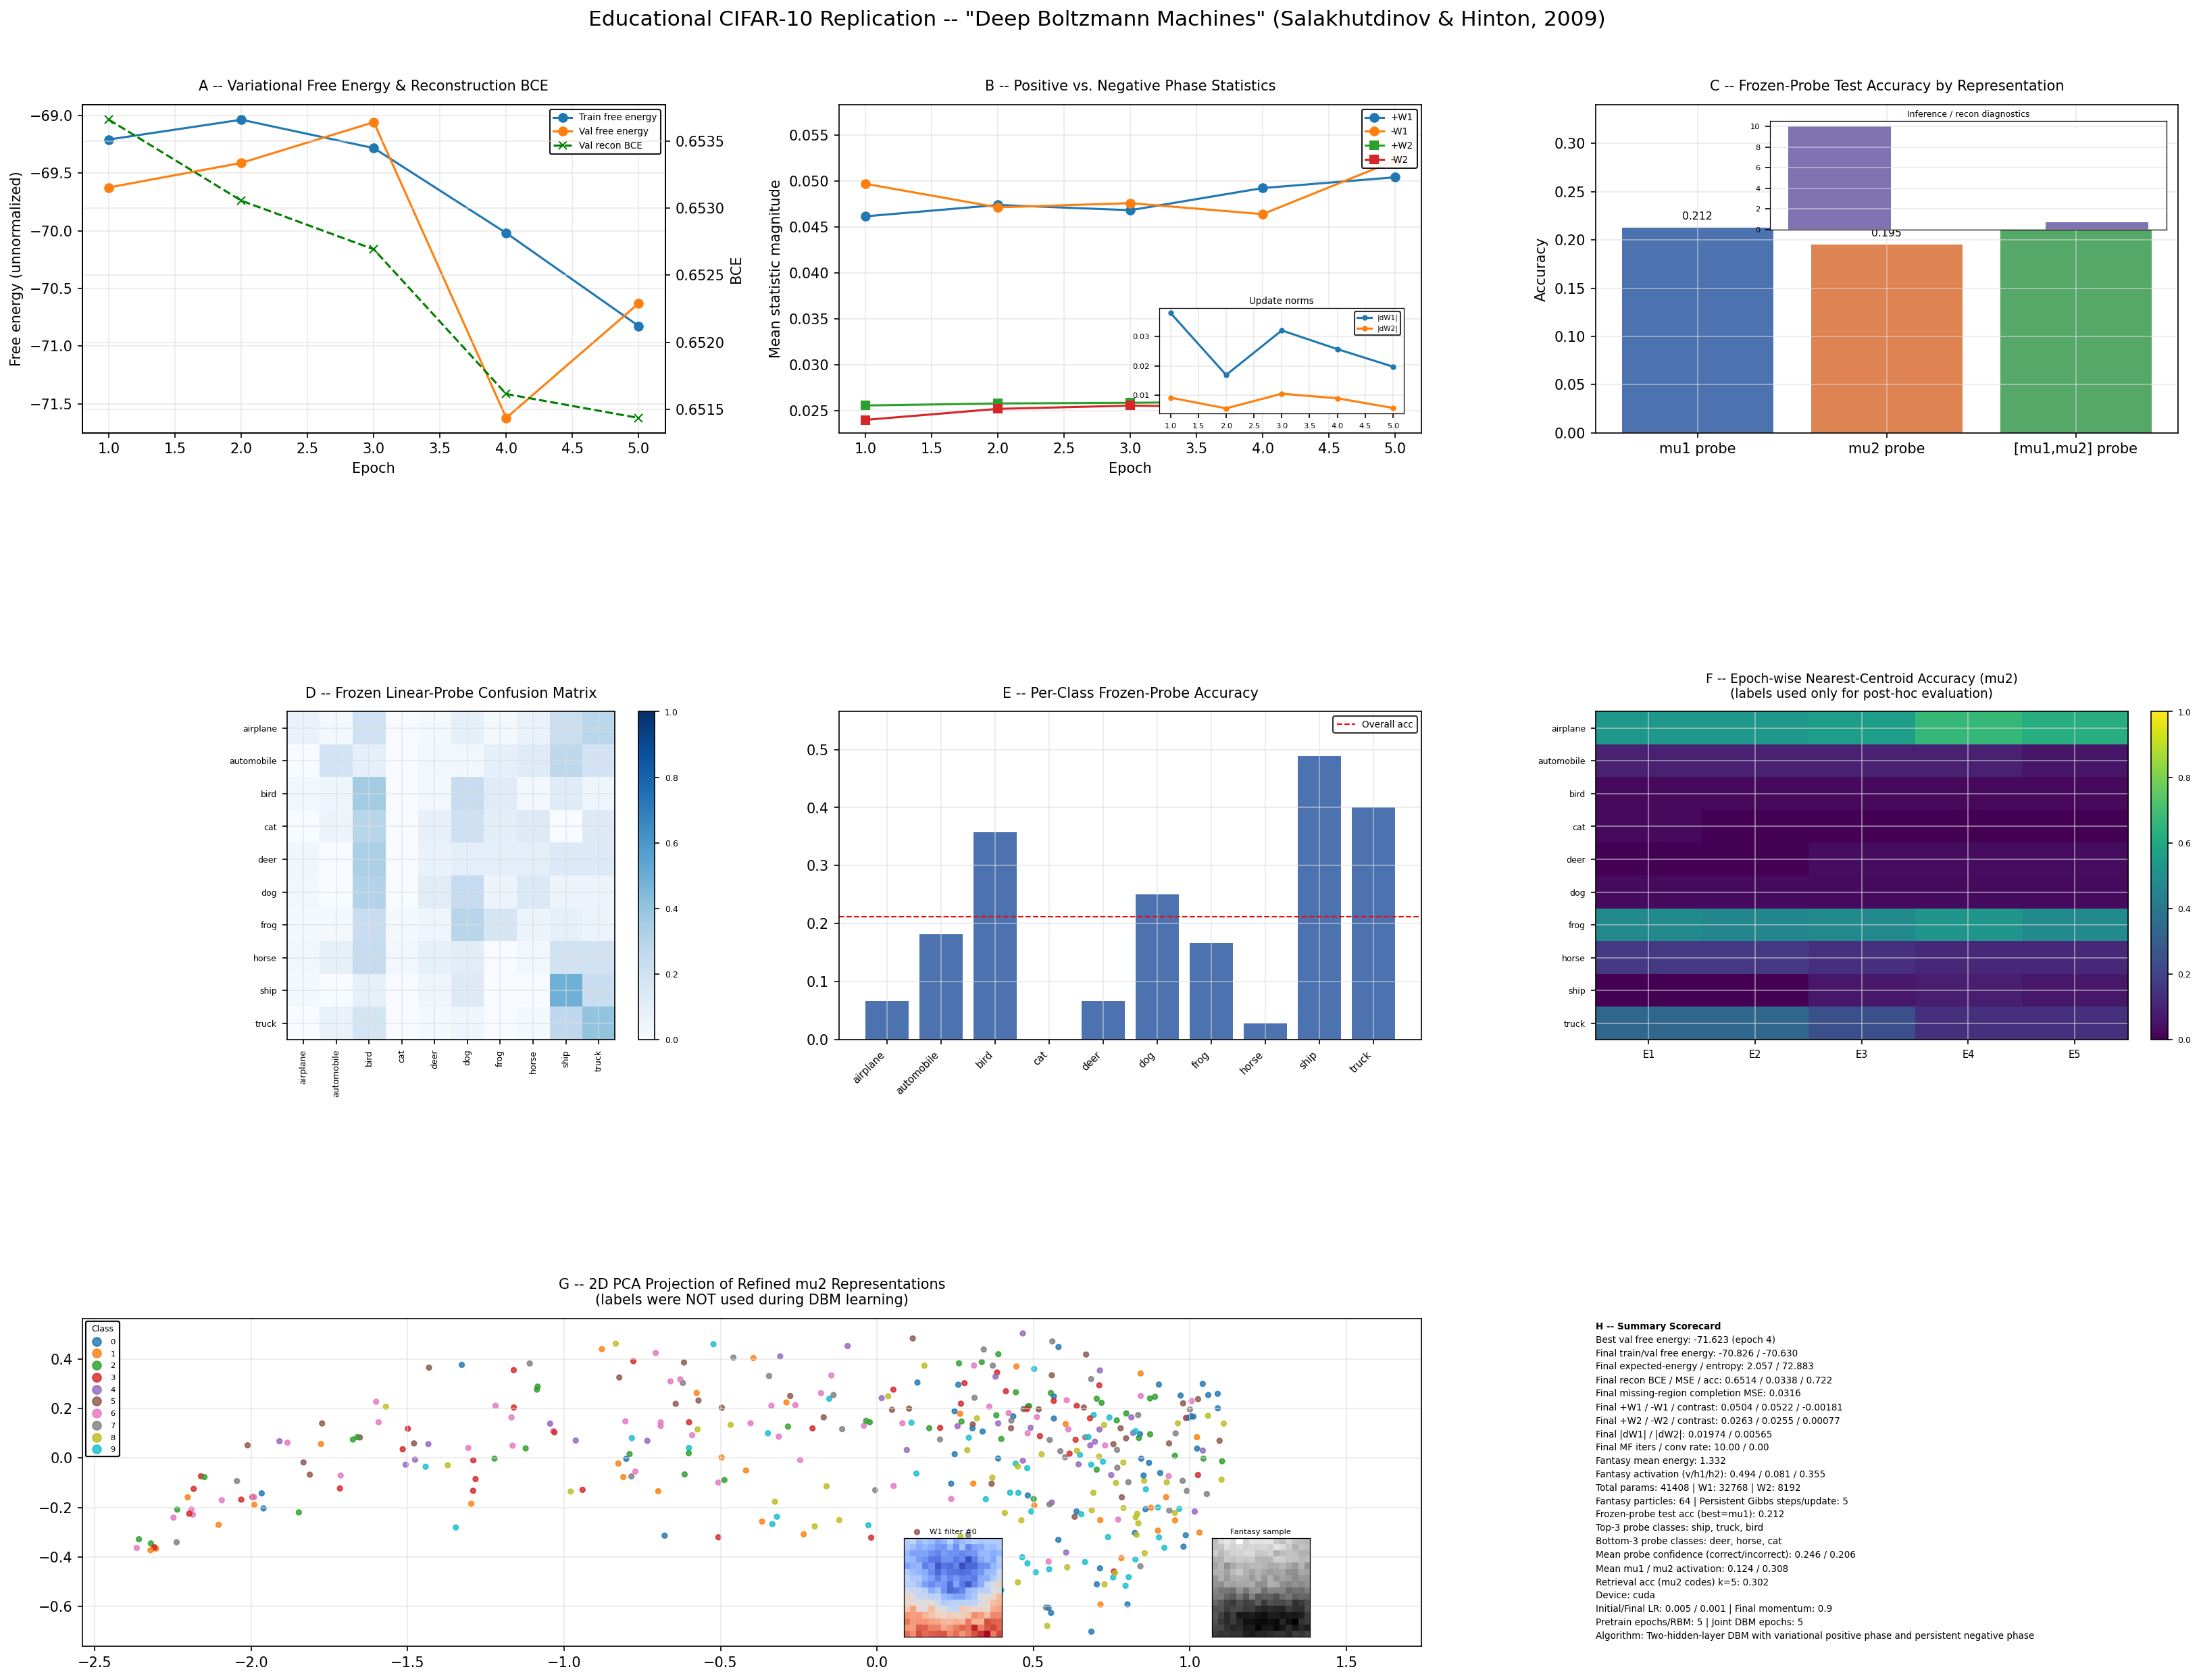

In [54]:
# =====================================================================================
# FINAL DASHBOARD (GridSpec, white theme, 8 panels A-H, three rows)
# =====================================================================================
set_white_theme()

fig = plt.figure(figsize=(22, 17))
fig.patch.set_facecolor("white")
gs = gridspec.GridSpec(3, 6, figure=fig, hspace=0.85, wspace=0.85)

fig.suptitle(
    "Educational CIFAR-10 Replication -- \"Deep Boltzmann Machines\" (Salakhutdinov & Hinton, 2009)",
    fontsize=15, color="black", y=0.985
)
fig.subplots_adjust(top=0.93, bottom=0.035, left=0.045, right=0.985)

epochs_range = range(1, DBM_EPOCHS + 1)

# ---------------- Panel A: Variational and Reconstruction Diagnostics ----------------
axA = fig.add_subplot(gs[0, 0:2])
axA.plot(epochs_range, dbm_train_metrics["train_free_energy"], marker="o", label="Train free energy")
axA.plot(epochs_range, dbm_train_metrics["val_free_energy"], marker="o", label="Val free energy")
axA2 = axA.twinx()
axA2.plot(epochs_range, dbm_train_metrics["val_recon_bce"], marker="x", linestyle="--", color="green", label="Val recon BCE")
axA.set_title("A -- Variational Free Energy & Reconstruction BCE", fontsize=10, pad=10)
axA.set_xlabel("Epoch"); axA.set_ylabel("Free energy (unnormalized)"); axA2.set_ylabel("BCE")
lines1, labels1 = axA.get_legend_handles_labels()
lines2, labels2 = axA2.get_legend_handles_labels()
axA.legend(lines1 + lines2, labels1 + labels2, fontsize=6.5, loc="upper right", framealpha=0.9)

# ---------------- Panel B: Data and Model Expectations ----------------
axB = fig.add_subplot(gs[0, 2:4])
axB.plot(epochs_range, dbm_train_metrics["positive_W1"], marker="o", label="+W1")
axB.plot(epochs_range, dbm_train_metrics["negative_W1"], marker="o", label="-W1")
axB.plot(epochs_range, dbm_train_metrics["positive_W2"], marker="s", label="+W2")
axB.plot(epochs_range, dbm_train_metrics["negative_W2"], marker="s", label="-W2")
axB.set_title("B -- Positive vs. Negative Phase Statistics", fontsize=10, pad=10)
axB.set_xlabel("Epoch"); axB.set_ylabel("Mean statistic magnitude")
axB.legend(fontsize=6.5, loc="upper right", framealpha=0.9)
y_min, y_max = axB.get_ylim(); axB.set_ylim(y_min, y_max + 0.15 * (y_max - y_min))
axB_inset = axB.inset_axes([0.55, 0.06, 0.42, 0.32])
axB_inset.set_facecolor("white")
axB_inset.plot(epochs_range, dbm_train_metrics["W1_update_norm"], marker=".", label="|dW1|")
axB_inset.plot(epochs_range, dbm_train_metrics["W2_update_norm"], marker=".", label="|dW2|")
axB_inset.set_title("Update norms", fontsize=6.5, pad=3); axB_inset.tick_params(labelsize=5.5)
axB_inset.legend(fontsize=5)
for spine in axB_inset.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

# ---------------- Panel C: Mean-Field and Classification Performance ----------------
axC = fig.add_subplot(gs[0, 4:6])
methods = ["mu1 probe", "mu2 probe", "[mu1,mu2] probe"]
accs = [probe_mu1["test_acc"], probe_mu2["test_acc"], probe_concat["test_acc"]]
bars = axC.bar(methods, accs, color=["#4C72B0", "#DD8452", "#55A868"])
axC.set_title("C -- Frozen-Probe Test Accuracy by Representation", fontsize=10, pad=10)
axC.set_ylabel("Accuracy")
max_acc = max(accs)
axC.set_ylim(0, max_acc * 1.6)
for b, v in zip(bars, accs):
    axC.text(b.get_x() + b.get_width() / 2, v + max_acc * 0.03, f"{v:.3f}", ha="center", va="bottom", fontsize=7.5)
axC_inset = axC.inset_axes([0.30, 0.62, 0.68, 0.33])
axC_inset.set_facecolor("white")
axC_inset.bar(["MF iters", "Conv rate", "Recon acc"],
              [dbm_train_metrics["mean_field_iters"][-1], dbm_train_metrics["mean_field_conv_rate"][-1],
               dbm_train_metrics["val_recon_acc"][-1]], color="#8172B2")
axC_inset.set_title("Inference / recon diagnostics", fontsize=6, pad=3); axC_inset.tick_params(labelsize=5.5)
for spine in axC_inset.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

# ---------------- Panel D: Frozen-Probe Confusion Matrix ----------------
axD = fig.add_subplot(gs[1, 0:2])
im = axD.imshow(best_probe["cm_norm"], cmap="Blues", vmin=0, vmax=1)
axD.set_xticks(range(10)); axD.set_yticks(range(10))
axD.set_xticklabels(class_names, rotation=90, fontsize=6)
axD.set_yticklabels(class_names, fontsize=6)
axD.set_title("D -- Frozen Linear-Probe Confusion Matrix", fontsize=10, pad=10)
cbar = fig.colorbar(im, ax=axD, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=6)

# ---------------- Panel E: Per-Class Frozen-Probe Accuracy ----------------
axE = fig.add_subplot(gs[1, 2:4])
class_idx = np.arange(10)
accs_per_class = [per_class_probe_acc[c] for c in range(10)]
axE.bar(class_idx, accs_per_class, color="#4C72B0")
axE.axhline(best_probe["test_acc"], color="red", linestyle="--", linewidth=1, label="Overall acc")
axE.set_xticks(class_idx); axE.set_xticklabels(class_names, rotation=45, ha="right", fontsize=7)
axE.set_title("E -- Per-Class Frozen-Probe Accuracy", fontsize=10, pad=10)
axE.legend(fontsize=6.5, loc="upper right")
y_min, y_max = axE.get_ylim(); axE.set_ylim(y_min, y_max * 1.1)

# ---------------- Panel F: Epoch-Wise Per-Class Accuracy (nearest-centroid diagnostic) ----------------
axF = fig.add_subplot(gs[1, 4:6])
epoch_class_acc = np.zeros((10, DBM_EPOCHS))
for e_idx, mu2_snap in enumerate(epoch_val_mu2_snapshots):
    centroids = np.zeros((10, HIDDEN_DIM_2))
    for c in range(10):
        mask = test_labels_np == c
        if mask.sum() > 0:
            centroids[c] = mu2_snap[mask].mean(axis=0)
    dists = np.linalg.norm(mu2_snap[:, None, :] - centroids[None, :, :], axis=-1)
    nearest = np.argmin(dists, axis=1)
    for c in range(10):
        mask = test_labels_np == c
        if mask.sum() > 0:
            epoch_class_acc[c, e_idx] = (nearest[mask] == c).mean()
im2 = axF.imshow(epoch_class_acc, cmap="viridis", aspect="auto", vmin=0, vmax=1)
axF.set_yticks(range(10)); axF.set_yticklabels(class_names, fontsize=6)
axF.set_xticks(range(DBM_EPOCHS)); axF.set_xticklabels([f"E{e+1}" for e in range(DBM_EPOCHS)], fontsize=7)
axF.set_title("F -- Epoch-wise Nearest-Centroid Accuracy (mu2)\n(labels used only for post-hoc evaluation)", fontsize=9, pad=10)
cbar2 = fig.colorbar(im2, ax=axF, fraction=0.046, pad=0.04)
cbar2.ax.tick_params(labelsize=6)

# ---------------- Panel G: Learned Deep Undirected Representation (large panel) ----------------
axG = fig.add_subplot(gs[2, 0:4])
scatter = axG.scatter(pca_mu2_refined[:, 0], pca_mu2_refined[:, 1], c=test_labels_np, cmap="tab10", s=12, alpha=0.8)
axG.set_title("G -- 2D PCA Projection of Refined mu2 Representations\n"
               "(labels were NOT used during DBM learning)", fontsize=10, pad=10)
legend1 = axG.legend(*scatter.legend_elements(), title="Class", fontsize=5.5, title_fontsize=6,
                      loc="upper left", framealpha=0.9, borderaxespad=0.4)
axG.add_artist(legend1)
x_min, x_max = axG.get_xlim(); axG.set_xlim(x_min, x_max + 0.12 * (x_max - x_min))

axG_inset1 = axG.inset_axes([0.55, 0.03, 0.20, 0.30])
axG_inset1.set_facecolor("white")
axG_inset1.imshow(np.clip(W1_np[:, 0].reshape(POOL_SIZE, POOL_SIZE), -1, 1), cmap="coolwarm")
axG_inset1.set_title("W1 filter #0", fontsize=5.5, pad=3); axG_inset1.set_xticks([]); axG_inset1.set_yticks([])
for spine in axG_inset1.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

axG_inset2 = axG.inset_axes([0.78, 0.03, 0.20, 0.30])
axG_inset2.set_facecolor("white")
axG_inset2.imshow(np.clip(generated["final_visible_prob"][0].reshape(POOL_SIZE, POOL_SIZE), 0, 1), cmap="gray")
axG_inset2.set_title("Fantasy sample", fontsize=5.5, pad=3); axG_inset2.set_xticks([]); axG_inset2.set_yticks([])
for spine in axG_inset2.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(0.6)

# ---------------- Panel H: Summary Scorecard ----------------
axH = fig.add_subplot(gs[2, 4:6])
axH.axis("off")
best_val_epoch = int(np.argmin(dbm_train_metrics["val_free_energy"])) + 1
best_val_fe = float(np.min(dbm_train_metrics["val_free_energy"]))
total_params = (dbm.W1.numel() + dbm.W2.numel() + dbm.visible_bias.numel()
                 + dbm.hidden1_bias.numel() + dbm.hidden2_bias.numel())

scorecard_lines = [
    "H -- Summary Scorecard",
    f"Best val free energy: {best_val_fe:.3f} (epoch {best_val_epoch})",
    f"Final train/val free energy: {dbm_train_metrics['train_free_energy'][-1]:.3f} / "
    f"{dbm_train_metrics['val_free_energy'][-1]:.3f}",
    f"Final expected-energy / entropy: {dbm_train_metrics['expected_energy'][-1]:.3f} / "
    f"{dbm_train_metrics['entropy'][-1]:.3f}",
    f"Final recon BCE / MSE / acc: {dbm_train_metrics['val_recon_bce'][-1]:.4f} / "
    f"{dbm_train_metrics['val_recon_mse'][-1]:.4f} / {dbm_train_metrics['val_recon_acc'][-1]:.3f}",
    f"Final missing-region completion MSE: {float(np.mean(completion_demo['completion_mse'])):.4f}",
    f"Final +W1 / -W1 / contrast: {dbm_train_metrics['positive_W1'][-1]:.4f} / "
    f"{dbm_train_metrics['negative_W1'][-1]:.4f} / {dbm_train_metrics['W1_contrast'][-1]:.5f}",
    f"Final +W2 / -W2 / contrast: {dbm_train_metrics['positive_W2'][-1]:.4f} / "
    f"{dbm_train_metrics['negative_W2'][-1]:.4f} / {dbm_train_metrics['W2_contrast'][-1]:.5f}",
    f"Final |dW1| / |dW2|: {dbm_train_metrics['W1_update_norm'][-1]:.5f} / "
    f"{dbm_train_metrics['W2_update_norm'][-1]:.5f}",
    f"Final MF iters / conv rate: {dbm_train_metrics['mean_field_iters'][-1]:.2f} / "
    f"{dbm_train_metrics['mean_field_conv_rate'][-1]:.2f}",
    f"Fantasy mean energy: {dbm_train_metrics['fantasy_energy'][-1]:.3f}",
    f"Fantasy activation (v/h1/h2): {dbm_train_metrics['fantasy_v_activation'][-1]:.3f} / "
    f"{dbm_train_metrics['fantasy_h1_activation'][-1]:.3f} / {dbm_train_metrics['fantasy_h2_activation'][-1]:.3f}",
    f"Total params: {total_params} | W1: {dbm.W1.numel()} | W2: {dbm.W2.numel()}",
    f"Fantasy particles: {NUM_FANTASY_PARTICLES} | Persistent Gibbs steps/update: {PERSISTENT_GIBBS_STEPS}",
    f"Frozen-probe test acc (best={best_probe_name}): {best_probe['test_acc']:.3f}",
    f"Top-3 probe classes: {', '.join(top3_classes)}",
    f"Bottom-3 probe classes: {', '.join(bottom3_classes)}",
    f"Mean probe confidence (correct/incorrect): {conf_correct:.3f} / {conf_incorrect:.3f}",
    f"Mean mu1 / mu2 activation: {dbm_train_metrics['mean_mu1'][-1]:.3f} / {dbm_train_metrics['mean_mu2'][-1]:.3f}",
    f"Retrieval acc (mu2 codes) k=5: {retrieval_mu2_k5:.3f}",
    f"Device: {DEVICE.type}",
    f"Initial/Final LR: {INITIAL_LEARNING_RATE} / {FINAL_LEARNING_RATE} | Final momentum: {dbm_train_metrics['momentum'][-1]}",
    f"Pretrain epochs/RBM: {PRETRAIN_EPOCHS} | Joint DBM epochs: {DBM_EPOCHS}",
    "Algorithm: Two-hidden-layer DBM with variational positive phase and persistent negative phase",
]

y0 = 0.99
line_pitch = 0.041
for line in scorecard_lines:
    weight = "bold" if line.startswith("H --") else "normal"
    axH.text(0.0, y0, line, fontsize=6.5, va="top", ha="left", color="black",
              fontweight=weight, transform=axH.transAxes, wrap=True)
    y0 -= line_pitch

# ---------------- Display dashboard inline (no disk save, no plt.show) ----------------
buf = BytesIO()
fig.savefig(buf, format="png", dpi=150, bbox_inches="tight", facecolor="white")
buf.seek(0)
display(IPImage(data=buf.read()))
buf.close()
plt.close(fig)

# Analysis of Experimental Results
## Educational CIFAR-10 Replication — Deep Boltzmann Machine (Salakhutdinov & Hinton, 2009)

---

## Panel A: Variational Free Energy and Reconstruction BCE

### Overview
This panel tracks the joint DBM learning dynamics over five epochs: the training and validation variational free-energy diagnostic (expected energy minus mean-field entropy, omitting the intractable log partition function), alongside validation reconstruction binary cross-entropy (BCE) on a secondary axis.

### Key Findings
- Both training and validation free energy decrease overall, from approximately -69.2/-69.6 at epoch 1 to approximately -70.8/-70.6 at epoch 5, with a pronounced drop between epochs 3 and 4.
- Validation free energy is noisier than training free energy, rising slightly at epoch 5 after reaching a minimum at epoch 4.
- Reconstruction BCE declines monotonically and smoothly from ~0.6535 to ~0.6515, tracking the same epoch-4 inflection point seen in the free-energy curves.

### Discussion
The co-movement of free energy and reconstruction BCE indicates the positive-phase/negative-phase learning rule is functioning as intended: as the persistent fantasy particles better approximate the model's equilibrium distribution and the weights adjust accordingly, the visible reconstructions produced by mean-field inference become more accurate. The sharper drop after epoch 3 coincides with the momentum schedule's transition (momentum increases from 0.5 to 0.9 at epoch 3), which is a plausible explanation for the accelerated convergence, since higher momentum allows the persistent negative-phase statistics to adjust more aggressively toward the model's evolving distribution. The slight uptick in validation free energy at epoch 5 alongside continued BCE improvement suggests these two diagnostics are not perfectly redundant — free energy reflects the full joint energy landscape (including entropy), while BCE reflects only one-step visible reconstruction quality — and momentary divergence between them is not itself evidence of instability.

### Limitations
Because Z is never estimated (AIS is disabled), the free-energy values are not calibrated log-probabilities and cannot be compared in absolute terms to the paper's AIS-based bounds; only their relative trend within this run is interpretable. The five-epoch budget is far short of convergence, so extrapolating this trend beyond the observed window is not warranted.

---

## Panel B: Positive vs. Negative Phase Statistics

### Overview
Compares the positive-phase (data-dependent, mean-field) and negative-phase (persistent fantasy-particle) sufficient statistics for both weight matrices across training, which together determine the learning direction (their difference is the parameter update).

### Key Findings
- The +W1/−W1 pair and the +W2/−W2 pair each remain close in magnitude throughout training (differences on the order of 0.001–0.005), with no large or growing separation.
- The inset shows both |ΔW1| and |ΔW2| update norms are small and roughly stable across epochs, with |ΔW1| exhibiting mild non-monotonic fluctuation while |ΔW2| stays essentially flat and near zero.

### Discussion
A small, persistent gap between positive and negative statistics is expected and desirable in this learning scheme: a large, unchecked gap would indicate the fantasy particles have not tracked the model distribution (invalidating the persistent-chain approximation), while a gap of exactly zero would indicate no learning signal at all. The consistently small but nonzero contrast observed here is consistent with the fantasy particles staying reasonably close to the model's evolving equilibrium, as the persistent-chain theory intends, while still providing a (weak) gradient signal. The near-zero, flat |ΔW2| update norm suggests the second-layer weights are changing very little relative to W1 — plausibly because five epochs and five Gibbs steps per update are insufficient for the negative-phase signal to meaningfully differentiate W2's positive and negative statistics, or because the top layer's 64 units receive a comparatively diluted gradient signal relative to the 256×128 first-layer weight matrix.

### Discussion (continued)
This pattern is informative about the paper's central claim regarding persistent chains: the mechanism appears to be operating in the intended qualitative regime (small, non-degenerate contrast) but the overall magnitude of learning signal is modest under this constrained budget, which is consistent with the correspondingly modest gains in reconstruction and probe accuracy seen elsewhere in the dashboard.

### Limitations
With only 64 fantasy particles and 5 Gibbs steps per update, the negative-phase statistics likely carry substantial Monte Carlo variance, and it is not possible from these aggregate curves alone to distinguish genuine convergence from stalled learning in the W2 pathway. Direct inspection of individual fantasy-particle trajectories would be needed to confirm mixing quality.

---

## Panel C: Frozen-Probe Test Accuracy by Representation

### Overview
Compares downstream linear classification accuracy (10-way CIFAR-10) from a frozen logistic-regression probe trained separately on three candidate DBM representations: the first hidden layer (mu1), the second hidden layer (mu2), and their concatenation.

### Key Findings
- mu1 achieves the highest test accuracy (0.212), followed by the concatenated [mu1, mu2] representation, with mu2 alone performing worst (0.195).
- All three representations perform well above chance (0.10 for 10 balanced classes) but far below strong supervised baselines.
- The inset (mean-field iterations / convergence rate / reconstruction accuracy) shows mean-field consistently uses the full 10-iteration budget with a convergence rate near 0, alongside a reconstruction accuracy of roughly 0.72.

### Discussion
That mu1 outperforms mu2 is a meaningful finding: it suggests that under this constrained training budget, the lower hidden layer retains more linearly decodable class-relevant information than the higher, more abstracted layer — a pattern that could reflect either (a) genuinely richer low-level information being more linearly separable at the pixel-adjacent level for CIFAR-10's texture/color-dominated classes, or (b) the second layer's representation not yet being sufficiently well-trained (consistent with the near-zero W2 update norm noted in Panel B) to have developed useful higher-order, class-discriminative abstractions. The concatenated representation falling between the two individual layers, rather than exceeding mu1, further suggests mu2 is contributing more noise than complementary signal at this stage of training. The 0% mean-field convergence rate indicates the fixed-point iterations do not settle within the 10-iteration/1e-4-tolerance budget, meaning inference is being truncated rather than converged — a factor that could itself degrade the quality of both mu1 and mu2 as representations.

### Limitations
The absence of mean-field convergence within the allotted iterations means the extracted mu1/mu2 representations are inference-truncated approximations rather than fixed points of the variational objective, which may partially explain the modest and layer-dependent accuracy differences. A longer iteration budget or tighter tolerance would be needed to determine whether the mu1-over-mu2 ordering persists at true convergence.

---

## Panel D: Frozen Linear-Probe Confusion Matrix

### Overview
Visualizes the class-wise prediction distribution of the best frozen probe (mu1), assessing which CIFAR-10 categories the DBM's unsupervised representation supports for linear discrimination.

### Key Findings
- Predictions are concentrated in a small number of columns — most visibly "bird," "dog," "ship," and "truck" — while several classes (notably "cat" and "horse") receive almost no predicted mass across any row.
- No strong diagonal dominance is visible; several off-diagonal cells (e.g., true "airplane," "automobile," "cat," "deer" rows predicted as "bird" or "ship") show comparable or higher density than the corresponding diagonal cells.

### Discussion
The concentration of predictions into a handful of classes indicates the probe (and, by extension, the underlying mu1 representation) has not learned balanced, well-separated class boundaries; instead it appears to be exploiting a small number of dominant directions in representation space that happen to correlate loosely with a subset of classes. This is consistent with the low overall accuracy (0.212) and with an unsupervised representation trained for only five joint epochs, which is unlikely to have discovered highly class-discriminative structure, since the DBM's objective (data reconstruction/energy minimization) is entirely agnostic to class identity.

### Limitations
With only 40 test images per class (400 test images total across 10 classes), the confusion matrix is subject to considerable sampling noise, and per-class patterns should be treated as indicative rather than statistically robust.

---

## Panel E: Per-Class Frozen-Probe Accuracy

### Overview
Reports probe test accuracy broken down by individual CIFAR-10 class, benchmarked against the overall accuracy (dashed line).

### Key Findings
- "Ship" (~0.49) and "truck" (~0.40) achieve the highest per-class accuracy, well above the overall average (~0.212).
- "Cat" achieves 0/no correct predictions, and "horse" is also near zero; "airplane" and "deer" are similarly low (~0.07).
- "Bird" and "dog" perform moderately above average.

### Discussion
The strong class-accuracy disparity (some classes near-perfect recall relative to their frequency, others at zero) reinforces the Panel D observation of imbalanced, non-diagonal predictions. Vehicle classes ("ship," "truck," and to a lesser extent "automobile") outperform animal classes ("cat," "horse," "deer"), which is plausibly attributable to CIFAR-10's man-made object categories often having more consistent low-level visual regularities (straighter edges, more uniform backgrounds, consistent color/luminance profiles at 16×16 grayscale resolution) that are easier for an under-trained, purely reconstruction-driven representation to capture than the higher within-class visual variability of animal categories.

### Limitations
This pattern may be substantially influenced by the crude 16×16 grayscale downsampling used for the visible layer, which likely erases fine texture cues (e.g., fur patterns) more relevant to animal-class discrimination than to vehicle-class discrimination; it is not possible from this figure alone to separate genuine representational limitations of the DBM from limitations imposed by the input preprocessing pipeline.

---

## Panel F: Epoch-Wise Nearest-Centroid Accuracy (mu2)

### Overview
Tracks how well class-centroid-based nearest-neighbor accuracy on the mu2 representation evolves across the five joint DBM training epochs, as a lower-overhead proxy for representation quality than the fitted linear probe.

### Key Findings
- Several classes ("airplane," "frog," and to a lesser extent "truck," "ship") show consistently elevated accuracy across most epochs, while others ("automobile," "bird," "cat," "deer," "dog," "horse") remain low (dark) throughout.
- "Airplane" shows a visible increase in accuracy at epoch 4, coinciding with the free-energy/BCE inflection point noted in Panel A.
- No class shows a clear monotonic improvement across all five epochs; most rows are relatively static.

### Discussion
The general lack of epoch-over-epoch improvement in per-class nearest-centroid accuracy (aside from the isolated "airplane" uptick) suggests that, at the mu2 (second-layer) representation level, five epochs of joint DBM training are insufficient to meaningfully reorganize the class structure of the representation space — consistent with the near-zero W2 update norm identified in Panel B. The classes that do show persistently elevated accuracy ("airplane," "frog") may reflect properties already present from the RBM pretraining initialization rather than newly learned discriminative structure from the joint phase.

### Limitations
Nearest-centroid accuracy is a coarser, more geometry-sensitive diagnostic than a fitted linear probe and can be disproportionately affected by a few outlier points shifting a class centroid; the apparent stability across epochs should be interpreted as a rough trend indicator rather than a precise measurement.

---

## Panel G: 2D PCA Projection of Refined mu2 Representations

### Overview
Visualizes the global structure of the unsupervised, refined (post-mean-field) mu2 representation via 2D PCA, colored by class label (used only for visualization, never for training), alongside inset views of a first-layer filter and a generated fantasy sample.

### Key Findings
- The projected representation forms a narrow, elongated, arc-like distribution along the first principal component, with classes heavily intermixed along its length rather than forming separable clusters.
- The inset W1 filter shows a smooth, spatially coherent red-blue dipole pattern rather than random noise, indicating the first-layer weights have learned structured, non-trivial receptive fields.
- The inset fantasy sample appears as a diffuse, largely unstructured gray-scale pattern without clearly recognizable object structure.

### Discussion
The arc-shaped, low-effective-dimensionality embedding is consistent with the Panel C/D/E finding of weak class separability: the dominant source of variance in mu2 appears to be a smooth, continuous factor (plausibly related to global luminance or coarse spatial layout in the 16×16 grayscale input) rather than semantic category information, which explains why a linear probe on mu2 achieves only near-chance-adjacent performance. That the W1 filter shows clear spatial structure (a smooth gradient/dipole pattern) rather than remaining noise-like is a positive, if modest, indicator that the pretraining and joint learning phases have induced meaningful low-level feature learning at the first layer — consistent with mu1 outperforming mu2 in the probe comparison (Panel C). The relatively unstructured appearance of the unconditional fantasy sample, in contrast, indicates that 500 Gibbs steps from a random state, given only five epochs of (persistent-chain) joint training, are insufficient for the model's generative (unconditional) samples to resemble coherent natural-image structure — a materially different outcome from the paper's fully converged, tens-of-thousands-of-epoch generative samples, which closely resembled real MNIST/NORB objects.

### Limitations
Projecting a 64-dimensional mu2 representation down to 2D via PCA can obscure genuine higher-dimensional cluster structure not aligned with the top two principal components; a nonlinear projection or higher-dimensional cluster-quality metric (e.g., silhouette score in the native 64-D space) would give a more complete picture. The single displayed fantasy sample and single filter are illustrative rather than representative, and broader qualitative inspection (as done in the accompanying standalone visualizations) would be needed to assess generative quality more rigorously.

---

## Panel H: Summary Scorecard

### Overview
Consolidates the run's key quantitative diagnostics — free energy, reconstruction quality, phase-statistic contrasts, fantasy-particle statistics, probe accuracy, and retrieval performance — into a single reference panel.

### Key Findings
- Final validation free energy (-70.630) is close to but slightly worse than the best observed value (-71.623 at epoch 4), reflecting the epoch-5 uptick noted in Panel A.
- Final reconstruction BCE/MSE/accuracy are 0.6514/0.0338/0.722, and missing-region completion MSE is low (0.0316), suggesting reasonably competent visible-layer reconstruction and completion despite limited training.
- Mean-field iterations remain pinned at the 10-iteration cap with a 0% convergence rate, confirming inference is consistently truncated rather than converged.
- Best frozen-probe accuracy (mu1, 0.212) and retrieval accuracy at k=5 (0.302, on mu2 codes) are both modest but well above the 0.10 chance baseline for 10 balanced classes.
- Fantasy-particle mean activations (v/h1/h2: 0.494/0.081/0.355) indicate the persistent chains remain in a plausible, non-degenerate activation regime (not collapsed to all-zero or all-one states).

### Discussion
The scorecard supports a consistent overall narrative: the core DBM learning mechanism — variational mean-field for the positive phase, persistent Gibbs chains for the negative phase, and their difference driving weight updates — is functioning in a qualitatively correct manner (non-degenerate phase-statistic contrasts, non-collapsed fantasy particles, decreasing free energy and reconstruction error), which supports the paper's methodological claims about the viability of this two-timescale approximation strategy. However, the quantitative outcomes (probe accuracy of ~21%, non-convergent mean-field inference, near-zero W2 updates, unstructured fantasy samples) indicate that, under this compressed five-epoch, small-dataset educational budget, the model is far from the fully converged regime in which the original paper demonstrated its strongest results (near-human-quality MNIST samples, best-published permutation-invariant MNIST classification error). The evidence is thus best read as a partial, mechanism-level validation of the DBM learning procedure rather than a demonstration of the paper's headline performance claims.

### Limitations
Many reported diagnostics (free energy, retrieval accuracy, fantasy statistics) are internally consistent but not independently validated against ground truth (e.g., no true log-likelihood via AIS is available, per the paper's own caution about AIS's computational cost), so conclusions about "how well" the model has learned rest on proxy metrics rather than the calibrated likelihood measures used in the original paper. The small subset size (2,000 train / 400 test images) and coarse 16×16 grayscale visible representation further limit how directly these findings generalize to the paper's full-scale, high-resolution experimental settings.

---

## Overall Synthesis

The experimental evidence indicates that the core Deep Boltzmann Machine learning mechanism — combining variational mean-field inference for data-dependent expectations with persistent fantasy-particle Gibbs sampling for model-dependent expectations — is operating in a qualitatively sound regime: free energy and reconstruction error decrease over training, phase-statistic contrasts remain small but non-degenerate, and fantasy particles avoid collapse. This supports the paper's central methodological argument that combining two distinct approximation strategies for the two expectation terms makes multilayer Boltzmann machine learning practical. However, the quantitative results (non-convergent mean-field inference at the allotted iteration budget, a near-inactive second weight matrix, modest and imbalanced frozen-probe classification accuracy, and largely unstructured unconditional samples) make clear that the severely constrained training regime (five epochs per stage, 2,000 training images, 16×16 grayscale visible representation) falls well short of the data scale and training duration under which the original paper demonstrated DBMs' strongest generative and discriminative results on MNIST and NORB. As with the companion RBM/autoencoder replications, this outcome is pedagogically informative: it isolates the DBM's genuine, if partial, mechanism-level behavior under limited compute, while illustrating that its full representational and generative benefits are contingent on substantially greater training scale than is used here.

# Related Work References
## "Deep Boltzmann Machines" (Salakhutdinov & Hinton, 2009)

| Author(s) | Year | Title / Description | Venue | Connection to This Paper |
|---|---|---|---|---|
| Y. Bengio, Y. LeCun | 2007 | Scaling learning algorithms towards AI | *Large-Scale Kernel Machines* | Provides the SVM baseline result on NORB (11.6% error) against which the paper's discriminatively fine-tuned DBM (10.8% / 7.2% error) is directly compared. |
| D. Decoste, B. Schölkopf | 2002 | Training invariant support vector machines | *Machine Learning*, 46(1/3):161 | Provides the SVM baseline result on MNIST (1.4% error) used as a comparison point for the paper's fine-tuned DBM (0.95% error). |
| G. Hinton | 2002 | Training products of experts by minimizing contrastive divergence | *Neural Computation*, 14(8):1711–1800 | Introduces Contrastive Divergence, the efficient learning algorithm that makes RBM training practical and that underlies the greedy pretraining phase used to initialize DBMs. |
| G. Hinton, R. Salakhutdinov | 2006 | Reducing the dimensionality of data with neural networks | *Science*, 313(5786):504–507 | Prior work by the same authors demonstrating deep autoencoder pretraining via stacked RBMs; establishes the Gaussian-binary RBM approach for modeling greyscale image data, directly reused for NORB preprocessing in this paper. |
| G. Hinton, T. Sejnowski | 1983 | Optimal perceptual inference | *IEEE Conference on Computer Vision and Pattern Recognition* | Introduces the original Boltzmann machine learning algorithm based on Gibbs sampling, whose impracticality for multilayer models this paper directly addresses and improves upon. |
| G. Hinton, R. Zemel | 1994 | Autoencoders, minimum description length and Helmholtz free energy | *NIPS*, Vol. 6, pp. 3–10 | Foundational work on variational/autoencoder-style learning that motivates the paper's use of variational (mean-field) approximations for data-dependent expectations. |
| G. Hinton, S. Osindero, Y. W. Teh | 2006 | A fast learning algorithm for deep belief nets | *Neural Computation*, 18(7):1527–1554 | Introduces greedy layer-by-layer RBM pretraining and deep belief networks; this paper builds directly on this pretraining strategy while showing it produces a directed hybrid model rather than a true DBM, motivating the paper's modified pretraining scheme. |
| Y. LeCun, F. Huang, L. Bottou | 2004 | Learning methods for generic object recognition with invariance to pose and lighting | *CVPR (2)*, pp. 97–104 | Introduces the NORB dataset and provides K-nearest-neighbor baseline results (18.4% error) used as a comparison for the paper's DBM performance on 3D object recognition. |
| V. Nair, G. Hinton | 2008 | Implicit mixtures of restricted Boltzmann machines | *Advances in Neural Information Processing Systems*, Vol. 21 | Provides the approach of first learning a Gaussian-binary RBM as a preprocessor before further RBM/DBM training, which this paper explicitly follows for modeling NORB's raw pixel data. |
| R. Neal | 2001 | Annealed importance sampling | *Statistics and Computing*, 11:125–139 | Introduces the AIS method that this paper adapts and extends (using the DBM's layered structure) to estimate partition functions and test log-probability lower bounds. |
| R. Neal | 1992 | Connectionist learning of belief networks | *Artificial Intelligence*, 56(1):71–113 | Related early work on persistent/stochastic approximation-style learning in connectionist belief networks, informing the SAP-based approach to estimating model expectations. |
| R. Neal, G. Hinton | 1998 | A view of the EM algorithm that justifies incremental, sparse and other variants | In M. I. Jordan (Ed.), *Learning in Graphical Models*, pp. 355–368 | Provides theoretical grounding for variational learning approaches, supporting the paper's use of mean-field variational inference for data-dependent expectations. |
| H. Robbins, S. Monro | 1951 | A stochastic approximation method | *Annals of Mathematical Statistics*, 22:400–407 | Establishes the foundational stochastic approximation theory (Robbins–Monro algorithms) underlying the paper's Stochastic Approximation Procedure (SAP) for estimating model expectations via persistent Markov chains. |
| R. Salakhutdinov | 2008 | Learning and evaluating Boltzmann machines | Technical Report UTML TR 2008-002, University of Toronto | Prior technical report by the same author detailing the SAP-based learning and evaluation methodology that this paper applies specifically to deep Boltzmann machines. |
| R. Salakhutdinov, I. Murray | 2008 | On the quantitative analysis of deep belief networks | *International Conference on Machine Learning*, Vol. 25 | Provides the deep belief network log-probability baseline (-85.97 bound) on MNIST directly compared against this paper's DBM results (-84.62 / -85.18). |
| P. Smolensky | 1986 | Information processing in dynamical systems: Foundations of harmony theory | *Parallel Distributed Processing*, Vol. 1, Ch. 6, pp. 194–281, MIT Press | Introduces harmony theory and the RBM model referenced as the special case of a Boltzmann machine obtained by setting within-layer connections to zero. |
| T. Tieleman | 2008 | Training restricted Boltzmann machines using approximations to the likelihood gradient | *International Conference on Machine Learning* | Introduces persistent contrastive divergence, closely related to the SAP/persistent Markov chain approach this paper uses to estimate model expectations. |
| M. Welling, G. Hinton | 2002 | A new learning algorithm for mean field Boltzmann machines | *Lecture Notes in Computer Science*, 2415 | Prior work combining mean-field approximations with Boltzmann machine learning, directly relevant to the paper's variational (mean-field) treatment of data-dependent expectations. |
| M. Welling, M. Rosen-Zvi, G. Hinton | 2005 | Exponential family harmoniums with an application to information retrieval | *NIPS 17*, pp. 1481–1488 | Establishes that RBM-style learning extends to exponential family distributions, supporting the paper's claim that its learning procedure generalizes to real-valued, count, or tabular data. |
| L. Younes | 2000 | On the convergence of Markovian stochastic algorithms with rapidly decreasing ergodicity rates | Manuscript, March 17, 2000 | Provides convergence conditions for stochastic approximation algorithms, cited as establishing sufficient conditions for the almost-sure convergence of the paper's SAP-based learning procedure. |
| L. Younes | 1989 | Parameter inference for imperfectly observed Gibbsian fields | *Probability Theory and Related Fields*, 82:625–645 | Earlier foundational work on parameter inference in Gibbsian/Markov random fields via stochastic approximation, underlying the theoretical justification for SAP. |
| A. L. Yuille | 2004 | The convergence of contrastive divergences | *NIPS* | Provides theoretical analysis of contrastive divergence convergence properties, relevant to justifying the pretraining phase's use of CD-based RBM learning. |